<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/07_10_2025_Taller_en_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller en clase: 07/10/2025**

#**Base de datos: wheather_feature - variable de interes: wind_speed**
#Julian David Morales Pineda

In [2]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('wheather_feature.txt')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'wheather_feature.txt' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


#separamos la variable de interes

In [3]:
wind_speed_data = df['wind_speed']
display(wind_speed_data.head())

,wind_speed
0,1
1,1
2,0
3,0
4,0


#Señal en el tiempo

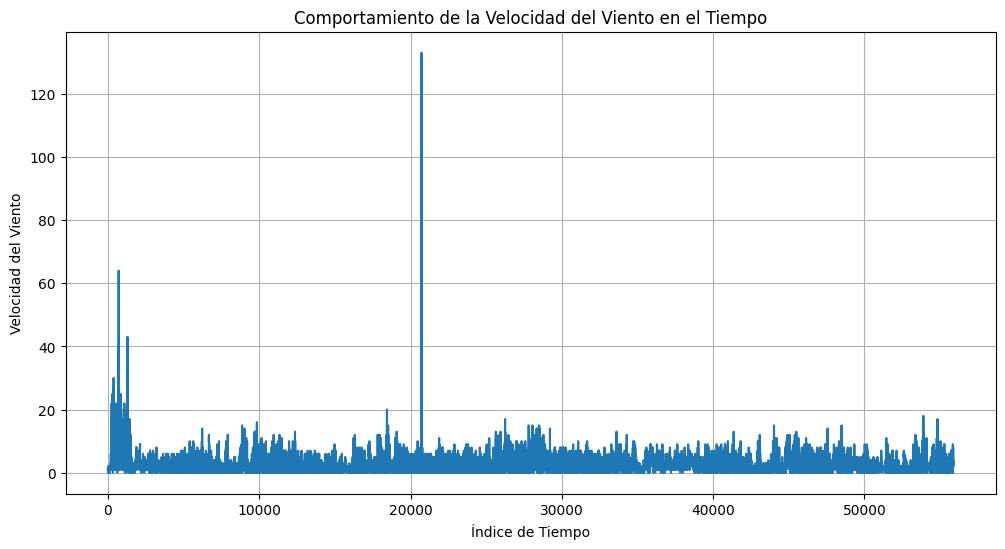

In [4]:
import matplotlib.pyplot as plt

# Take the variable of interest (wind_speed_data)
# This variable already holds the 'wind_speed' column extracted earlier
wind_speed_time_series = wind_speed_data

# Create a figure and an axes for the plot
plt.figure(figsize=(12, 6)) # Set the size of the plot

# Plot the time series data
# We are plotting the wind_speed values against their index (representing time)
plt.plot(wind_speed_time_series)

# Add a title to the plot
plt.title('Comportamiento de la Velocidad del Viento en el Tiempo')

# Add labels to the x and y axes
plt.xlabel('Índice de Tiempo')
plt.ylabel('Velocidad del Viento')

# Add a grid to the plot for better readability
plt.grid(True)

# Display the plot
plt.show()

#**Espectro de la señal**

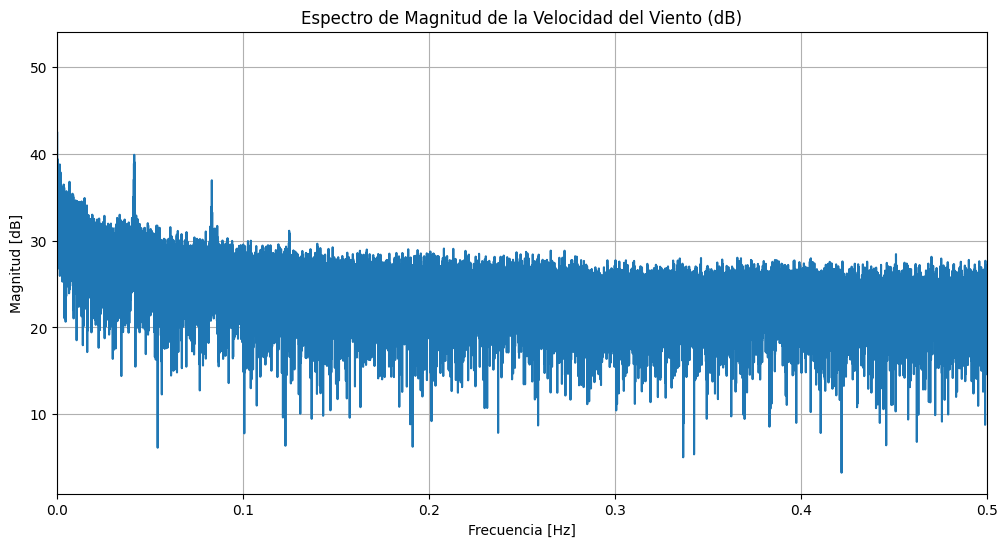

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Remove any potential NaN values from the time series data before performing FFT
wind_speed_time_series_clean = wind_speed_time_series.dropna()

# Calculate sampling frequency (assuming hourly data, so delta_t = 1 hour)
# If your data has a different sampling interval, adjust delta_t accordingly.
delta_t = 1 # Assuming hourly data, so 1 hour between samples
fs = 1 / delta_t # Sampling frequency in Hz (or cycles per hour)
nyquist = fs / 2 # Nyquist frequency

# Perform the Fast Fourier Transform (FFT)
fft_result = np.fft.fft(wind_speed_time_series_clean)

# Get the magnitude of the spectrum and convert to decibels (dB)
# We only need the first half for a real signal (positive frequencies)
fft_magnitude = np.abs(fft_result[:len(fft_result)//2])
# Add a small epsilon to avoid log(0)
epsilon = 1e-10
fft_magnitude_db = 10 * np.log10(fft_magnitude + epsilon)

# Create the frequency axis
# The frequency values are from 0 up to the Nyquist frequency
frequencies = np.fft.fftfreq(len(wind_speed_time_series_clean), d=delta_t)[:len(fft_result)//2]

# Create a figure and axes for the spectrum plot
plt.figure(figsize=(12, 6))

# Plot the magnitude spectrum in dB
plt.plot(frequencies, fft_magnitude_db)

# Add title and labels
plt.title('Espectro de Magnitud de la Velocidad del Viento (dB)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')

# Add a grid for better readability
plt.grid(True)

# Set x-axis limit to Nyquist frequency for a wider view
plt.xlim([0, nyquist])

# Display the plot
plt.show()

##Autocorrelacion antes del filtrado

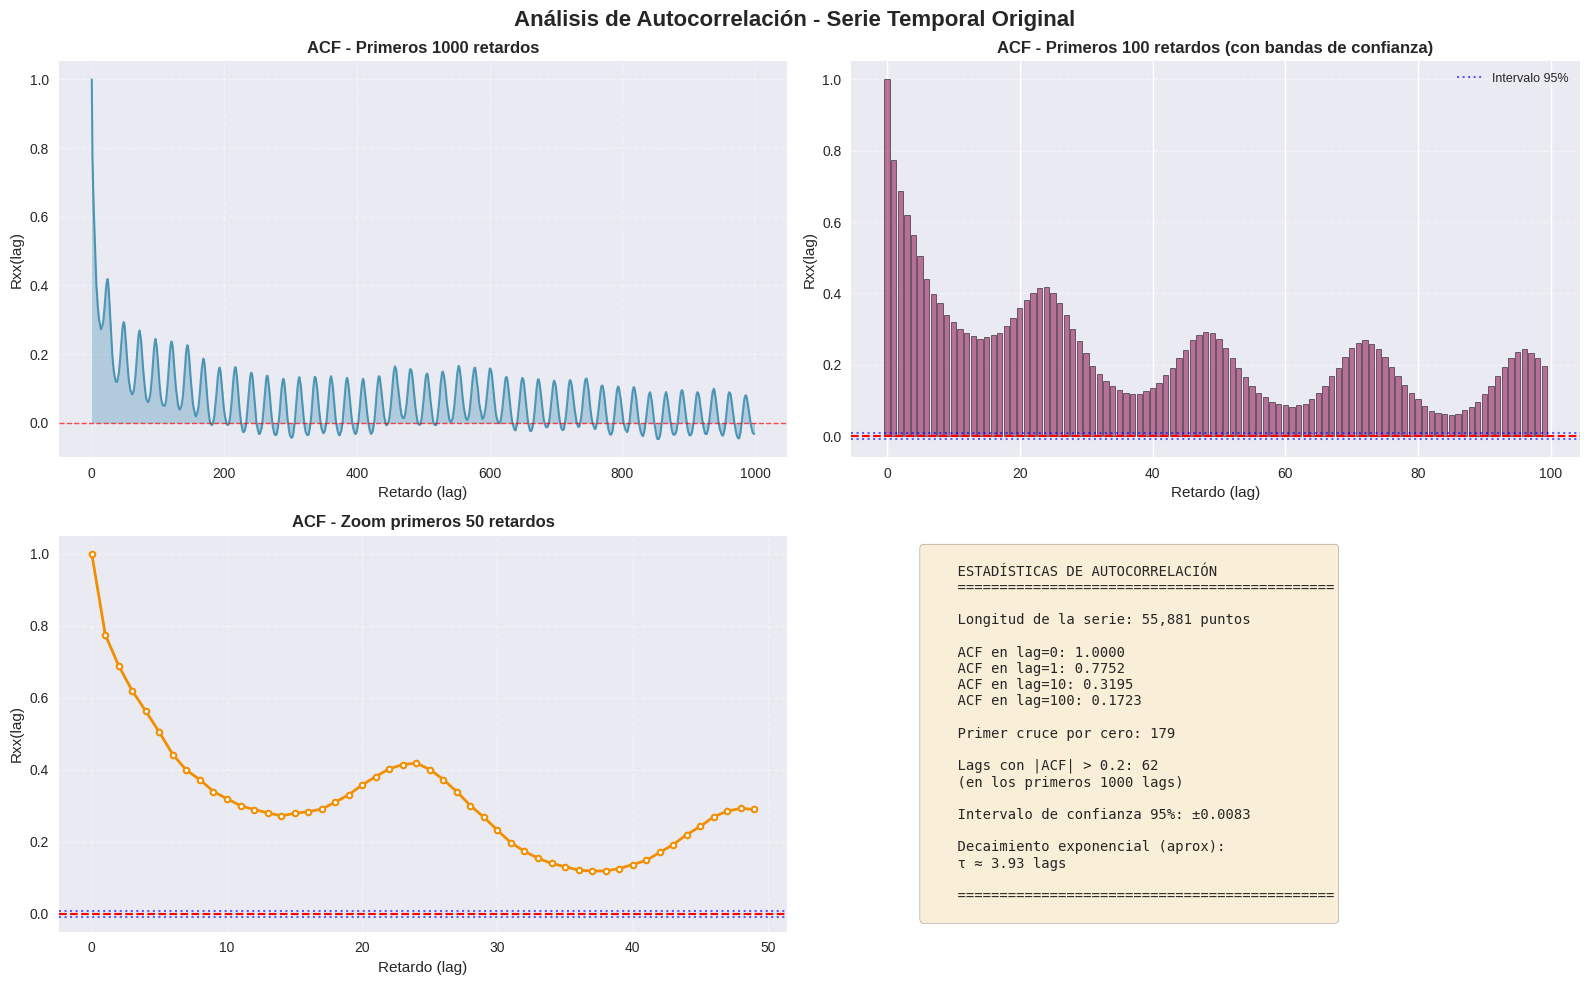


RESUMEN DE AUTOCORRELACIÓN
ACF máxima (lag>0): 0.7752 en lag 1
ACF mínima: -0.0798 en lag 14688



In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# Usar la señal original
x_original = torch.tensor(wind_speed_time_series_clean.values, dtype=torch.float32)

if len(x_original) < 2:
    print("Error: La serie es demasiado corta para calcular autocorrelación.")
else:
    # Quitar la media
    x_mean_original = x_original - torch.mean(x_original)

    # FFT y PSD
    fft_x_original = torch.fft.fft(x_mean_original)
    psd_x_original = torch.abs(fft_x_original) ** 2

    # Autocorrelación via IFFT
    acf_full_original = torch.fft.ifft(psd_x_original)
    acf_original = torch.real(acf_full_original)
    acf_original = acf_original / acf_original[0]  # Normalizar en lag=0

    # Solo retardos positivos
    N_original = len(x_original)
    acf_original = acf_original[:N_original]
    lags_original = torch.arange(len(acf_original))

    # ===============================
    # Visualización mejorada
    # ===============================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Análisis de Autocorrelación - Serie Temporal Original',
                 fontsize=16, fontweight='bold')

    # 1. ACF completa (primeros 1000 lags)
    max_lags_1 = min(1000, len(acf_original))
    axes[0, 0].plot(lags_original[:max_lags_1].numpy(),
                    acf_original[:max_lags_1].numpy(),
                    color='#2E86AB', linewidth=1.5, alpha=0.8)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[0, 0].fill_between(lags_original[:max_lags_1].numpy(),
                            acf_original[:max_lags_1].numpy(),
                            0, alpha=0.3, color='#2E86AB')
    axes[0, 0].set_title('ACF - Primeros 1000 retardos', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0, 0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0, 0].grid(True, linestyle='--', alpha=0.4)

    # 2. ACF detallada (primeros 100 lags) - barras
    max_lags_2 = min(100, len(acf_original))
    axes[0, 1].bar(lags_original[:max_lags_2].numpy(),
                   acf_original[:max_lags_2].numpy(),
                   color='#A23B72', width=0.8, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    # Bandas de confianza (aproximadas)
    conf_level = 1.96 / torch.sqrt(torch.tensor(len(x_original), dtype=torch.float32))
    axes[0, 1].axhline(y=conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6, label='Intervalo 95%')
    axes[0, 1].axhline(y=-conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[0, 1].set_title('ACF - Primeros 100 retardos (con bandas de confianza)',
                         fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0, 1].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0, 1].legend(loc='upper right', fontsize=9)
    axes[0, 1].grid(True, linestyle='--', alpha=0.4, axis='y')

    # 3. ACF zoom (primeros 50 lags) - línea con marcadores
    max_lags_3 = min(50, len(acf_original))
    axes[1, 0].plot(lags_original[:max_lags_3].numpy(),
                    acf_original[:max_lags_3].numpy(),
                    color='#F18F01', linewidth=2, marker='o',
                    markersize=4, markerfacecolor='white',
                    markeredgewidth=1.5, markeredgecolor='#F18F01')
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[1, 0].axhline(y=conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[1, 0].axhline(y=-conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[1, 0].set_title('ACF - Zoom primeros 50 retardos', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[1, 0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[1, 0].grid(True, linestyle='--', alpha=0.4)

    # 4. Estadísticas y decaimiento
    axes[1, 1].axis('off')

    # Calcular estadísticas
    first_zero_crossing = torch.where(acf_original[:max_lags_1] < 0)[0]
    if len(first_zero_crossing) > 0:
        first_zero = first_zero_crossing[0].item()
    else:
        first_zero = "No encontrado"

    # Encontrar picos significativos
    threshold = 0.2
    significant_lags = torch.where(torch.abs(acf_original[:max_lags_1]) > threshold)[0]

    stats_text = f"""
    ESTADÍSTICAS DE AUTOCORRELACIÓN
    {'='*45}

    Longitud de la serie: {len(x_original):,} puntos

    ACF en lag=0: {acf_original[0].item():.4f}
    ACF en lag=1: {acf_original[1].item():.4f}
    ACF en lag=10: {acf_original[min(10, len(acf_original)-1)].item():.4f}
    ACF en lag=100: {acf_original[min(100, len(acf_original)-1)].item():.4f}

    Primer cruce por cero: {first_zero}

    Lags con |ACF| > {threshold}: {len(significant_lags)}
    (en los primeros {max_lags_1} lags)

    Intervalo de confianza 95%: ±{conf_level.item():.4f}

    Decaimiento exponencial (aprox):
    τ ≈ {-1/torch.log(torch.abs(acf_original[1])).item():.2f} lags

    {'='*45}
    """

    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                    verticalalignment='center', bbox=dict(boxstyle='round',
                    facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # Imprimir resumen en consola
    print("\n" + "="*50)
    print("RESUMEN DE AUTOCORRELACIÓN")
    print("="*50)
    print(f"ACF máxima (lag>0): {torch.max(acf_original[1:]).item():.4f} en lag {torch.argmax(acf_original[1:]).item() + 1}")
    print(f"ACF mínima: {torch.min(acf_original).item():.4f} en lag {torch.argmin(acf_original).item()}")
    print("="*50 + "\n")

#**Filtrado de la señal en pasa altas con espectro de magnitud filtrada, PSD, respuesta del filtro en frecuencia**

## 1️⃣ Planteamiento del problema

Se diseña un **filtro pasa-altas causal** que elimine la **componente DC**
(es decir, que tenga una **función de transferencia** \( H(0) = 0 \))
y que preserve la causalidad, de modo que la salida dependa solo de valores pasados y presentes de la señal de entrada.

Sea una señal aleatoria \( x(t) \) (en este caso, la **velocidad del viento**).
La señal filtrada \( y(t) \) es la convolución con la respuesta al impulso \( h(t) \):

$$
y(t) = (h * x)(t) = \int_{0}^{\infty} h(\lambda)\,x(t - \lambda)\,d\lambda
$$

La integral va desde \( 0 \) a \( \infty \) para cumplir la **condición de causalidad**:
el sistema no puede depender de valores futuros de \( x(t) \).

* * *

## 2️⃣ Condición de eliminación de la media

Si la señal de entrada tiene una media constante \( m_x = \mathbb{E}[x(t)] \),
entonces la media de la salida es:

$$
m_y = \mathbb{E}[y(t)] = m_x \int_{0}^{\infty} h(\lambda)\,d\lambda
$$

Para eliminar la media (o componente DC), debemos imponer que:

$$
\int_{0}^{\infty} h(\lambda)\,d\lambda = 0
$$

En el dominio de la frecuencia, esta condición equivale a:

$$
H(0) = 0
$$

donde \( H(\omega) = \mathcal{F}\{h(t)\} \) es la **función de transferencia** del filtro.

* * *

## 3️⃣ Ejemplo: filtro pasa-altas discreto

Para una señal discreta \( x[n] \), la convolución causal es:

$$
y[n] = \sum_{k=0}^{\infty} h[k]\,x[n - k]
$$

Un ejemplo simple de filtro pasa-altas que cumple \( H(0) = 0 \) es el **diferenciador discreto**:

$$
h[n] = \delta[n] - \delta[n - 1]
$$

$$
\Rightarrow y[n] = x[n] - x[n - 1]
$$

Su función de transferencia en el dominio Z es:

$$
H(z) = 1 - z^{-1}
$$

Y en frecuencia:

$$
H(e^{j\omega}) = 1 - e^{-j\omega}
$$

$$
|H(e^{j\omega})|^2 = 4\sin^2\left(\frac{\omega}{2}\right)
$$

Note que \( H(0) = 0 \), por lo que **elimina la componente DC**.

* * *

## 4️⃣ Filtro pasa-altas de Butterworth (IIR)

De manera más general, se puede usar un filtro **Butterworth pasa-altas** de orden \( N \),
cuya magnitud es:

$$
|H(j\omega)|^2 = \frac{1}{1 + \left(\frac{\omega_c}{\omega}\right)^{2N}}
$$

donde \( \omega_c = 2\pi f_c \) es la frecuencia de corte.

En el dominio digital (tras la transformación bilineal), se obtiene:

$$
H(z) = \frac{B(z)}{A(z)} = \frac{b_0 + b_1 z^{-1} + \cdots + b_N z^{-N}}{1 + a_1 z^{-1} + \cdots + a_N z^{-N}}
$$

El valor de \( H(0) \) se verifica numéricamente para garantizar que \( |H(0)| \approx 0 \).

* * *

## 5️⃣ Causalidad y transitorio

El filtro diseñado debe ser **causal**, es decir:

$$
h(t) = 0 \quad \text{para todo } t < 0
$$

En la práctica, esto se garantiza aplicando el filtrado con un **operador causal** (`lfilter` en Python),
que implementa la ecuación de diferencias recursiva del filtro IIR:

$$
y[n] = \sum_{k=0}^{M} b_k\,x[n-k] - \sum_{r=1}^{N} a_r\,y[n-r]
$$

Al aplicar el filtro a una señal con media distinta de cero, la salida presenta una
**transición temporal (régimen transitorio)** hasta alcanzar el estado estacionario:

$$
\lim_{n \to \infty} y[n] = 0
$$

para una entrada constante \( x[n] = C \).

* * *

## 6️⃣ Densidad espectral de potencia y correlación

La relación entre las **Densidades Espectrales de Potencia (PSD)** de entrada y salida es:

$$
S_y(\omega) = |H(e^{j\omega})|^2\,S_x(\omega)
$$

La **autocorrelación** de la salida se obtiene mediante la transformada inversa:

$$
R_y(\tau) = \frac{1}{2\pi} \int_{-\infty}^{\infty} S_y(\omega)\,e^{j\omega\tau}\,d\omega
$$

Y su varianza es simplemente:

$$
\sigma_y^2 = R_y(0) = \int_{-\infty}^{\infty} |H(e^{j\omega})|^2 S_x(\omega)\,\frac{d\omega}{2\pi}
$$

* * *

## 7️⃣ Interpretación física

- Si \( H(0) = 1 \) → el sistema **mantiene la media** (pasa-bajas).
- Si \( H(0) = 0 \) → el sistema **elimina la media** (pasa-altas).
- Si el sistema es causal, siempre aparece una **fase retardada** y una **transición temporal** antes del estado estacionario.

* * *

ANÁLISIS ESPECTRAL Y FILTRADO DE VELOCIDAD DEL VIENTO

✓ Base de datos cargada exitosamente
  Dimensiones: (178396, 17)
  Columnas disponibles: ['dt_iso', 'city_name', 'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'weather_id', 'weather_main', 'weather_description', 'weather_icon']

CARACTERÍSTICAS DE LA SEÑAL
Número total de muestras: 178,396
Frecuencia de muestreo: 1.0 Hz
Duración del registro: 178396.00 s (49.55 horas)
Resolución frecuencial Δf: 0.00000561 Hz
Frecuencia de Nyquist: 0.500000 Hz

──────────────────────────────────────────────────────────────────────
ESTADÍSTICAS DESCRIPTIVAS
──────────────────────────────────────────────────────────────────────
Media (μ):              2.4706 m/s
Desviación estándar (σ): 2.0959 m/s
Máximo:                 133.0000 m/s
Mínimo:                 0.0000 m/s
Mediana:                2.0000 m/s
Rango:                  133.0000 m/s

ANÁLISIS EN EL DOMINIO DE LA F

/tmp/ipython-input-4105157859.py:326: RuntimeWarning: divide by zero encountered in log10
  ax7.plot(w_filter[w_mask], 20 * np.log10(np.abs(h_filter[w_mask])),


✓ Gráfica principal guardada: 'wind_speed_analysis_optimized.png'


/tmp/ipython-input-4105157859.py:364: RuntimeWarning: divide by zero encountered in log10
  ax_mag.plot(w_filter[w_mask], 20 * np.log10(np.abs(h_filter[w_mask])),


✓ Respuesta del filtro guardada: 'filter_response_detailed.png'


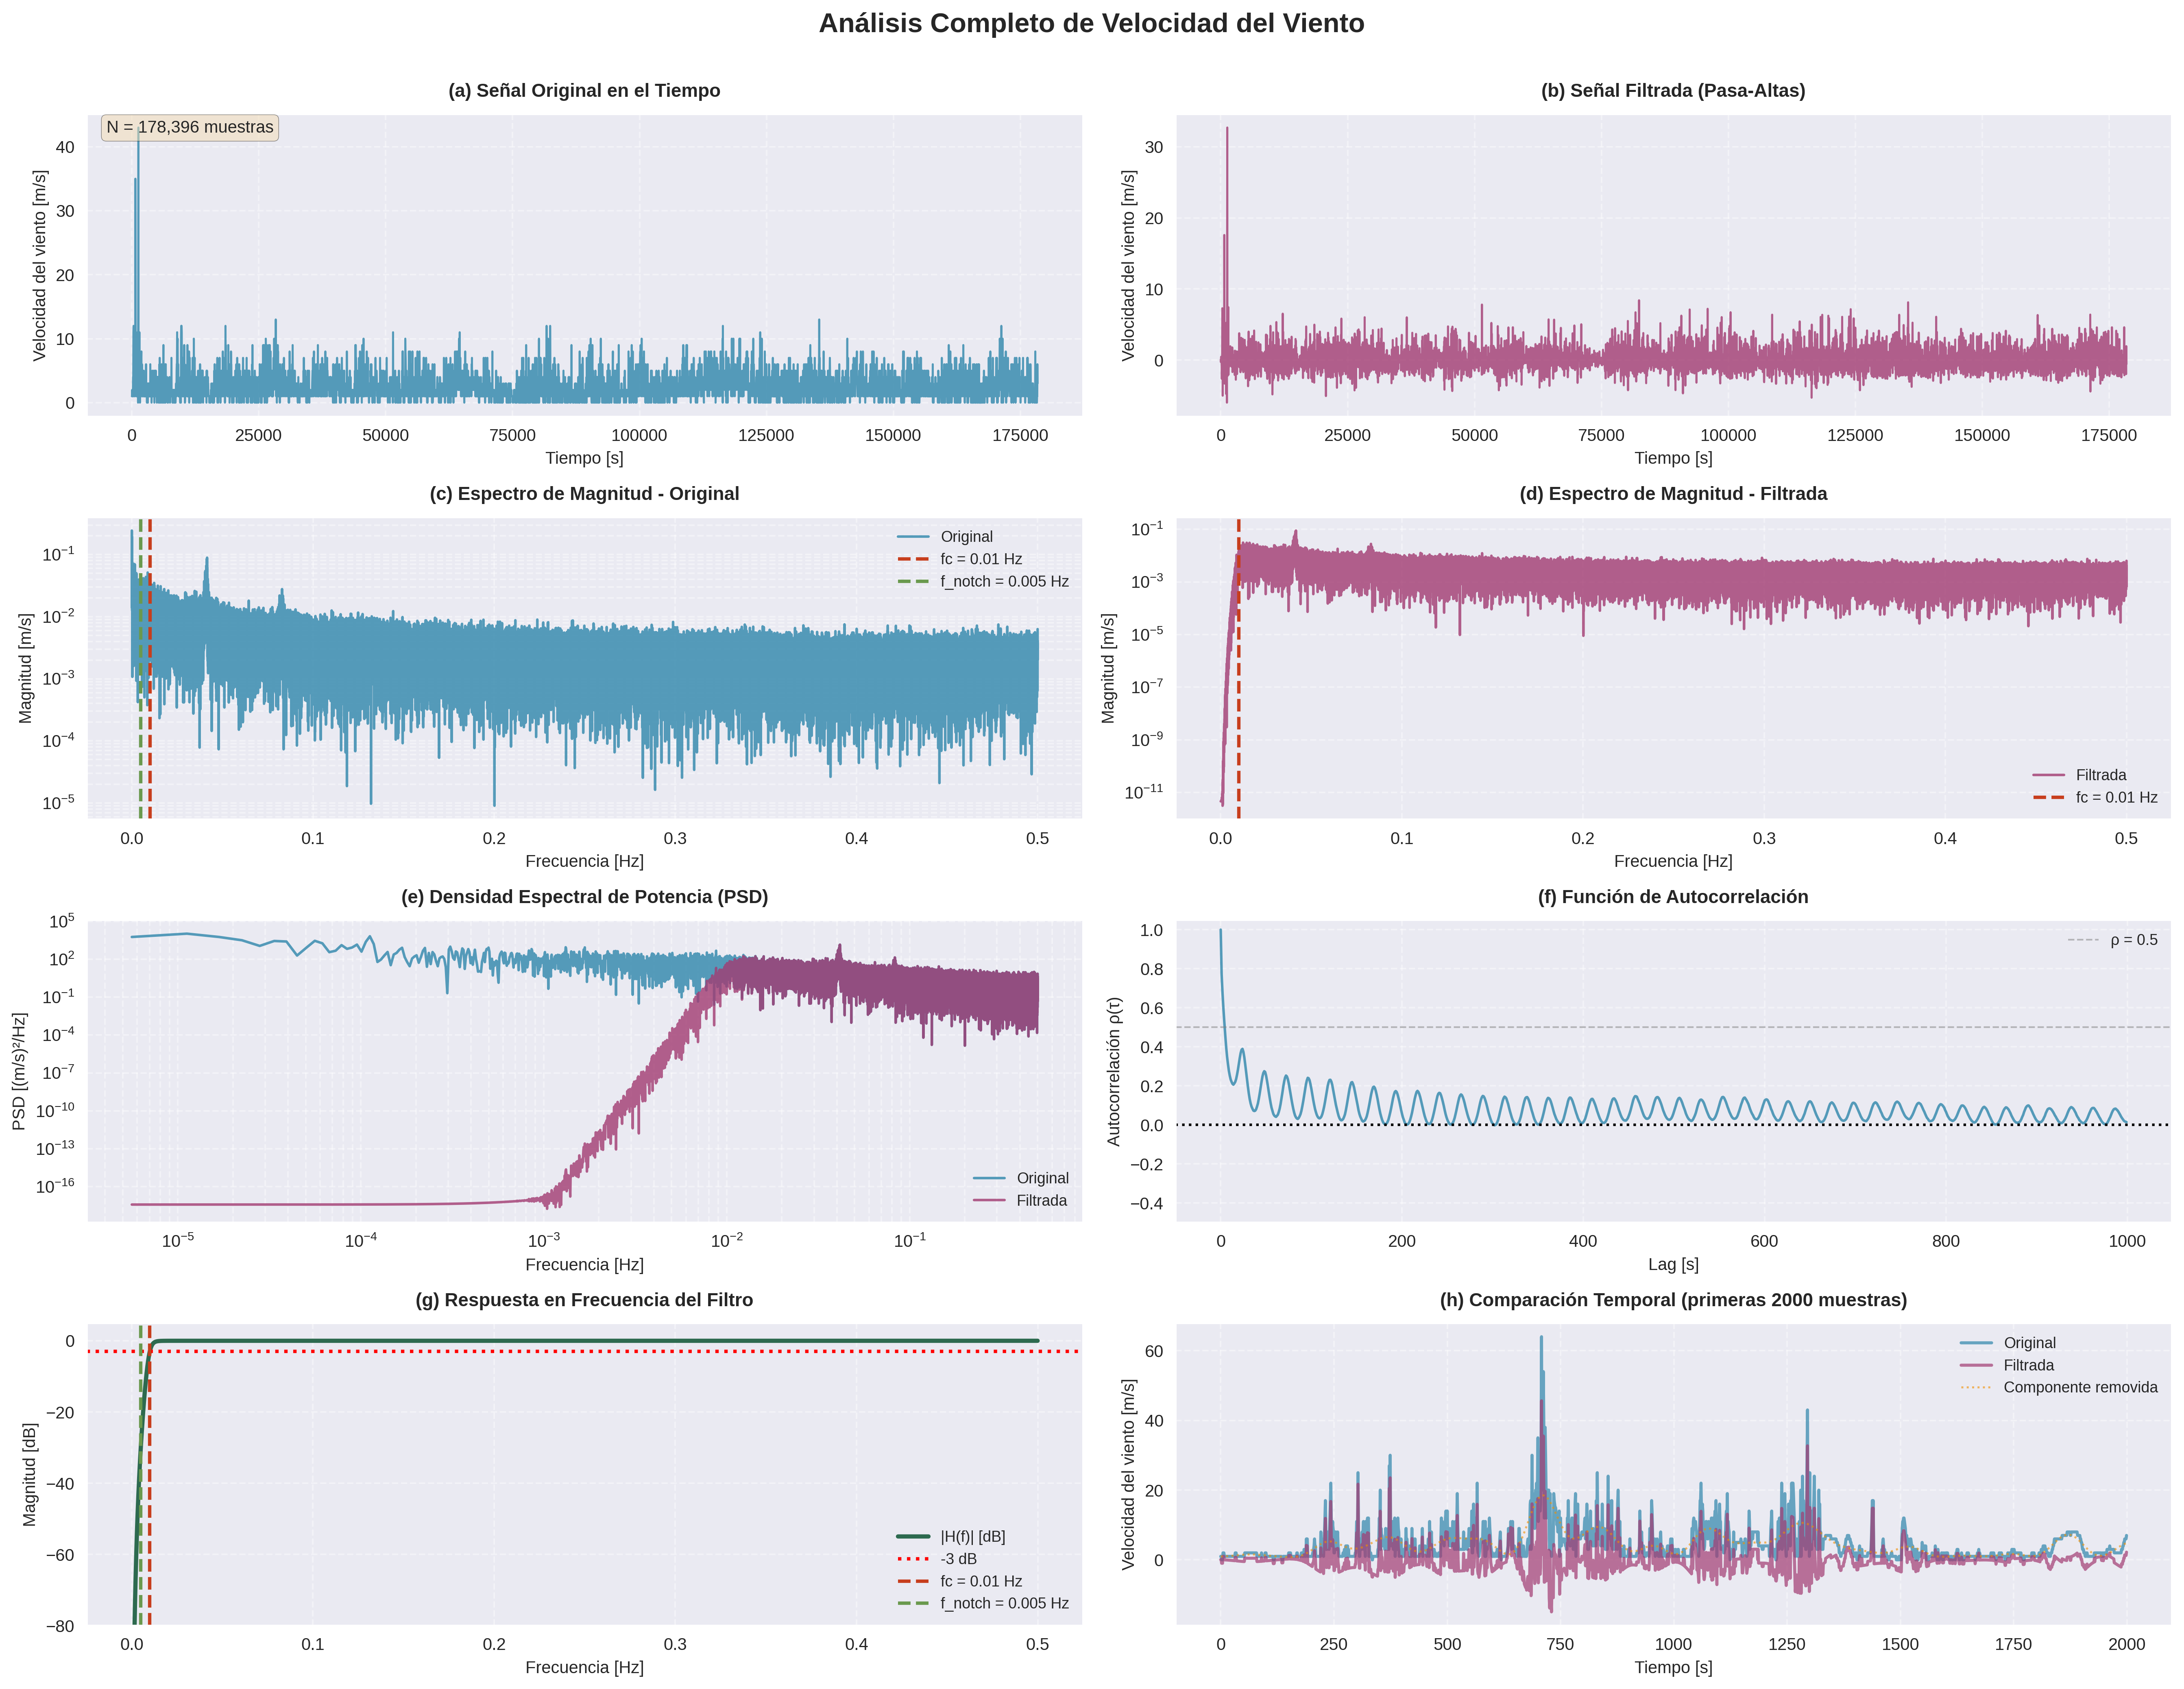

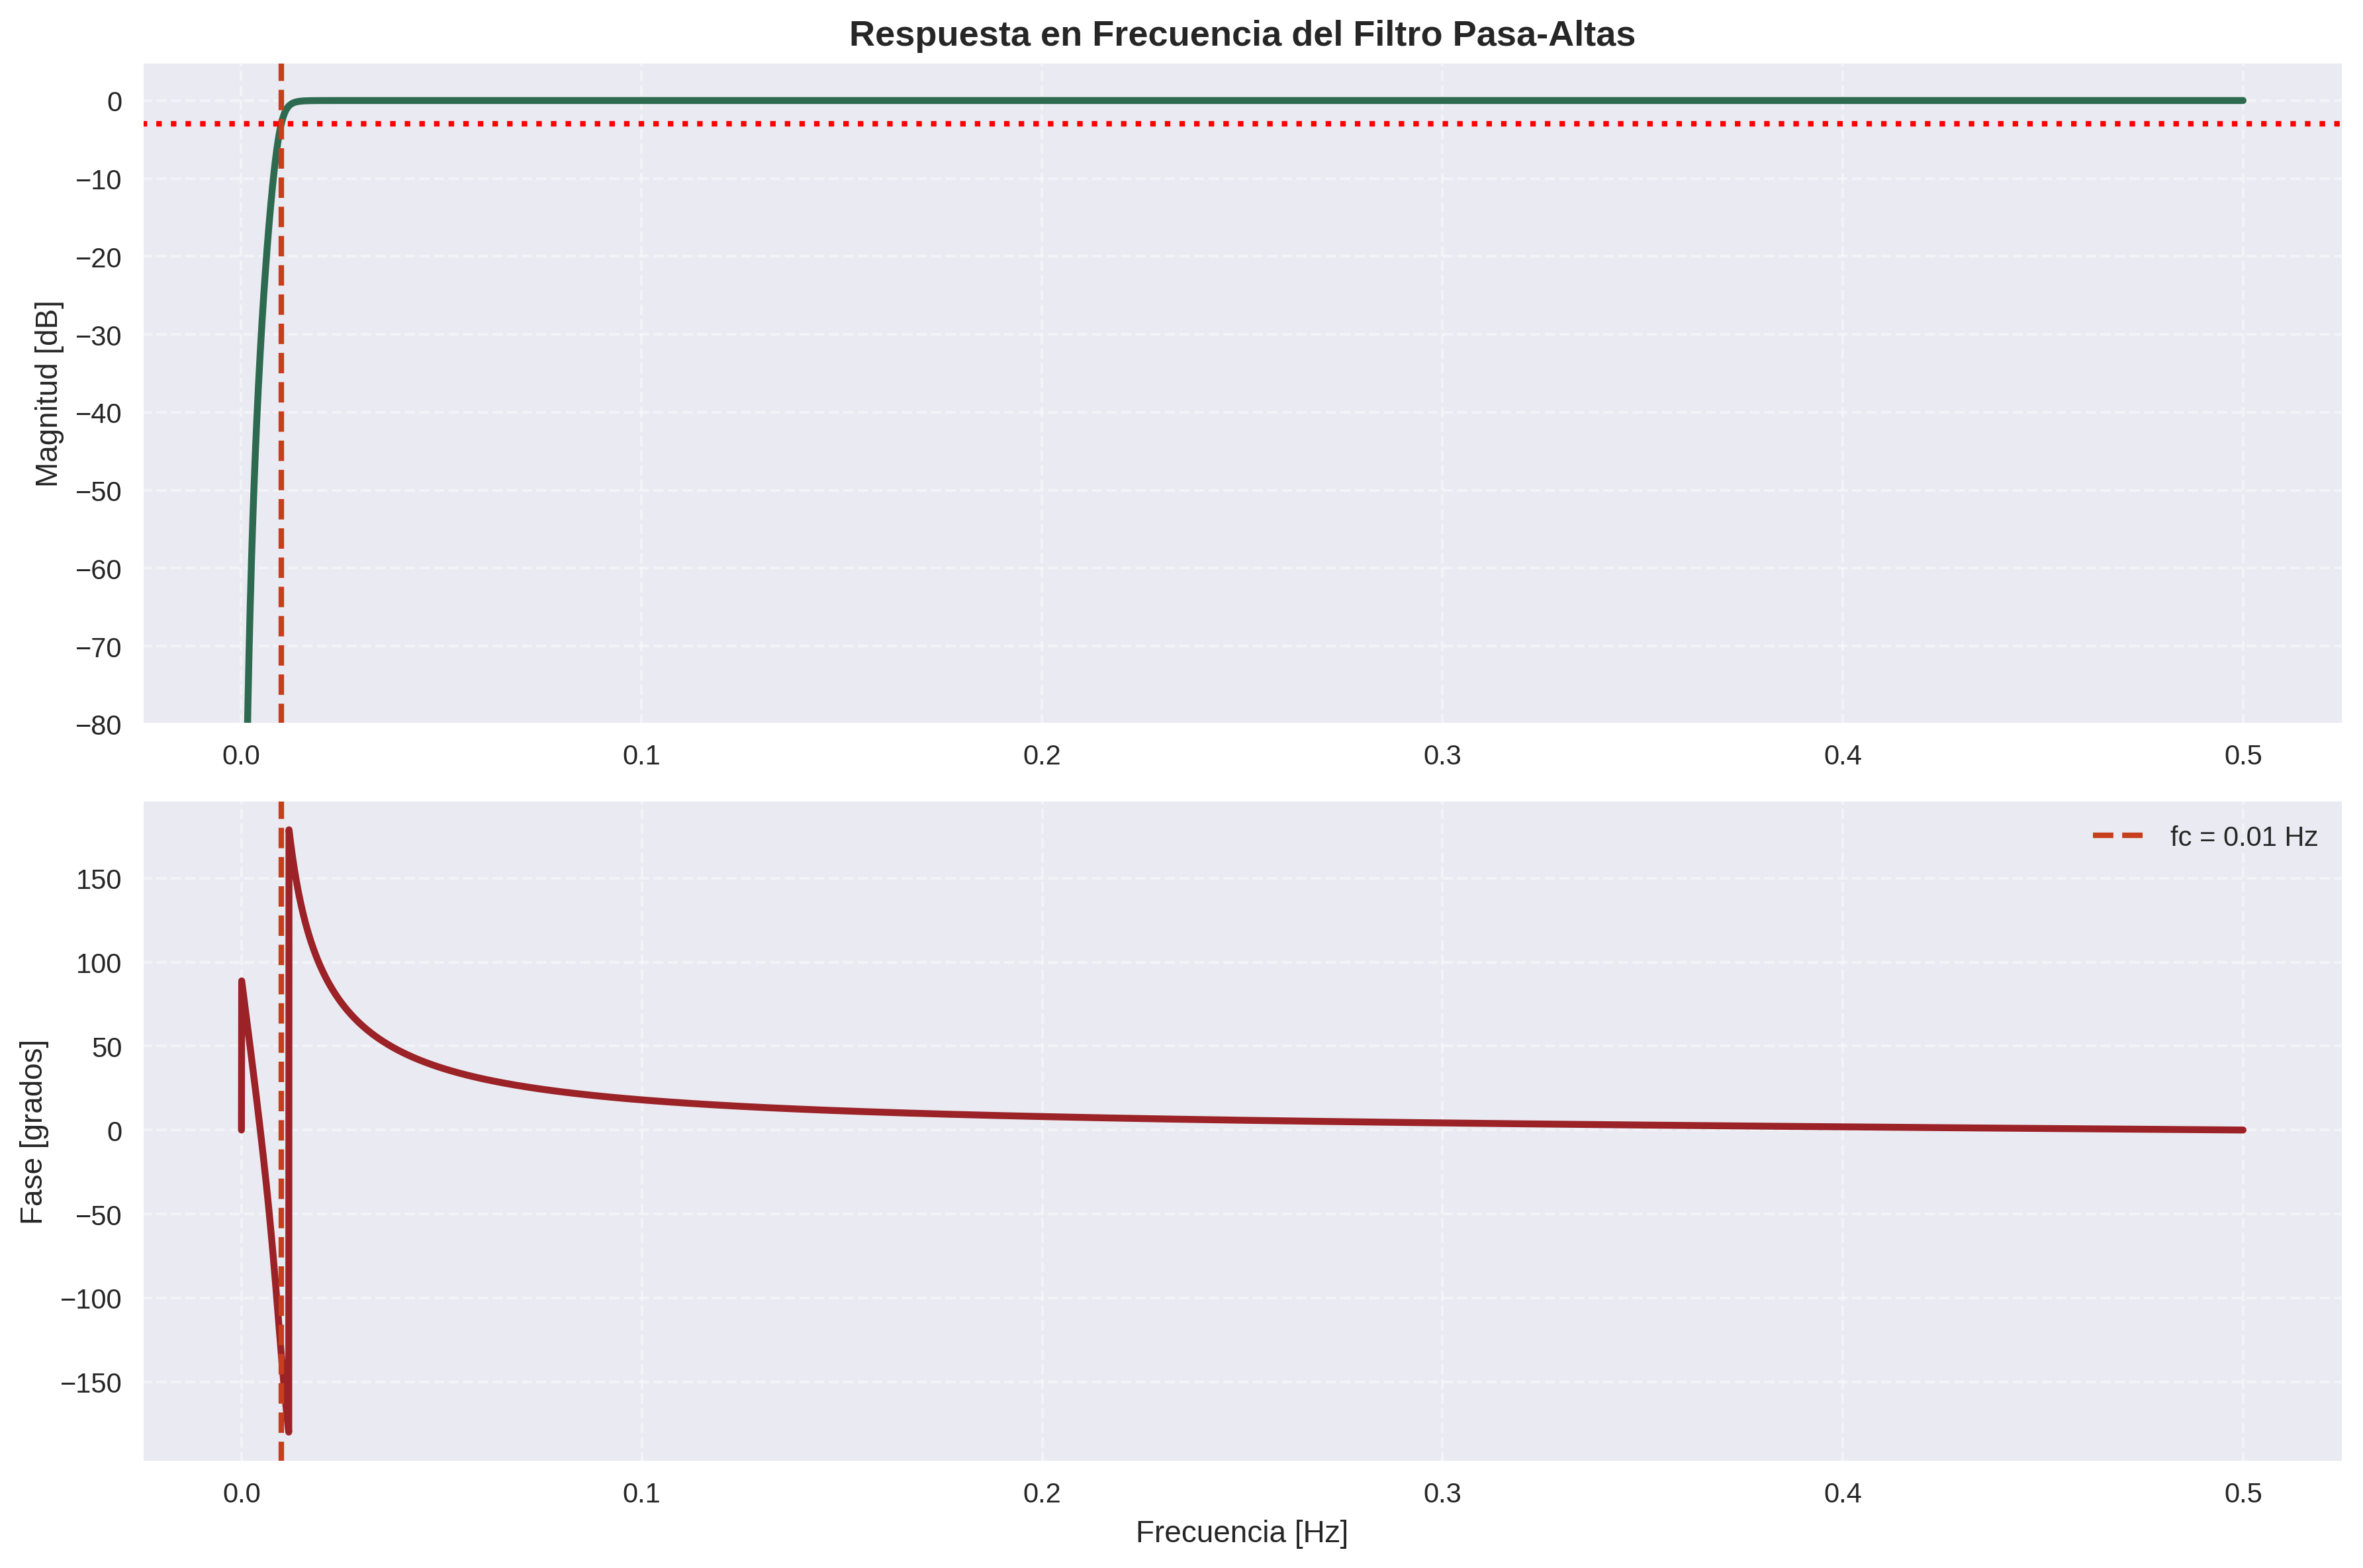


EXPORTANDO RESULTADOS
✓ Señales exportadas: 'wind_speed_filtered_results.csv'
✓ Análisis espectral exportado: 'wind_speed_spectral_analysis.csv'
✓ Resumen estadístico exportado: 'wind_speed_summary.csv'

✓✓✓ ANÁLISIS COMPLETADO EXITOSAMENTE ✓✓✓

Archivos generados:
  1. wind_speed_analysis_optimized.png (gráfica principal)
  2. filter_response_detailed.png (respuesta del filtro)
  3. wind_speed_filtered_results.csv (series temporales)
  4. wind_speed_spectral_analysis.csv (análisis frecuencial)
  5. wind_speed_summary.csv (resumen estadístico)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
# import torch # Removed PyTorch import

# Configuración de matplotlib para alta calidad
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3

# ====================
# 1. CARGA DE DATOS
# ====================
print("="*70)
print("ANÁLISIS ESPECTRAL Y FILTRADO DE VELOCIDAD DEL VIENTO")
print("="*70)

try:
    df = pd.read_csv('wheather_feature.txt')
    print("\n✓ Base de datos cargada exitosamente")
    print(f"  Dimensiones: {df.shape}")
    print(f"  Columnas disponibles: {list(df.columns)}")
except FileNotFoundError:
    print("❌ Error: Archivo 'wheather_feature.txt' no encontrado")
    exit()
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")
    exit()

# Extraer variable de interés
wind_speed_data = df['wind_speed'].values
N = len(wind_speed_data)

# ====================
# 2. PARÁMETROS DE LA SEÑAL
# ====================
# AJUSTAR SEGÚN TU BASE DE DATOS
# Ejemplos comunes:
# - Datos cada hora: fs = 1/3600 Hz
# - Datos cada 10 min: fs = 1/600 Hz
# - Datos cada minuto: fs = 1/60 Hz
fs = 1.0  # [Hz] - MODIFICAR ESTE VALOR

print(f"\n{'='*70}")
print("CARACTERÍSTICAS DE LA SEÑAL")
print(f"{'='*70}")
print(f"Número total de muestras: {N:,}")
print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Duración del registro: {N/fs:.2f} s ({N/fs/3600:.2f} horas)")
print(f"Resolución frecuencial Δf: {fs/N:.8f} Hz")
print(f"Frecuencia de Nyquist: {fs/2:.6f} Hz")

# Estadísticas descriptivas
print(f"\n{'─'*70}")
print("ESTADÍSTICAS DESCRIPTIVAS")
print(f"{'─'*70}")
print(f"Media (μ):              {np.mean(wind_speed_data):.4f} m/s")
print(f"Desviación estándar (σ): {np.std(wind_speed_data):.4f} m/s")
print(f"Máximo:                 {np.max(wind_speed_data):.4f} m/s")
print(f"Mínimo:                 {np.min(wind_speed_data):.4f} m/s")
print(f"Mediana:                {np.median(wind_speed_data):.4f} m/s")
print(f"Rango:                  {np.ptp(wind_speed_data):.4f} m/s")

# ====================
# 3. ANÁLISIS ESPECTRAL (FFT)
# ====================
print(f"\n{'='*70}")
print("ANÁLISIS EN EL DOMINIO DE LA FRECUENCIA")
print(f"{'='*70}")

# Remover tendencia (detrend) para mejorar análisis espectral
wind_detrended = signal.detrend(wind_speed_data)

# Aplicar ventana de Hanning para reducir fuga espectral
window = signal.windows.hann(N)
wind_windowed = wind_detrended * window

# Calcular FFT
fft_values = fft(wind_windowed)
fft_magnitude = np.abs(fft_values) * (2.0/N)  # Normalización
frequencies = fftfreq(N, 1/fs)

# Frecuencias positivas únicamente
positive_freq_idx = frequencies > 0
freq_positive = frequencies[positive_freq_idx]
magnitude_positive = fft_magnitude[positive_freq_idx]

# Densidad Espectral de Potencia (PSD)
psd = magnitude_positive**2 / (fs/N)

# Identificar frecuencias dominantes
dominant_indices = np.argsort(magnitude_positive)[-10:][::-1]
print("\nFrecuencias dominantes (Top 10):")
print(f"{'Rank':<6} {'Frecuencia (Hz)':<18} {'Período':<20} {'Magnitud':<12} {'Potencia':<12}")
print(f"{'-'*70}")
for i, idx in enumerate(dominant_indices, 1):
    freq_val = freq_positive[idx]
    period = 1/freq_val if freq_val > 0 else np.inf
    period_str = f"{period:.2f} s" if period < 3600 else f"{period/3600:.2f} h"
    print(f"{i:<6} {freq_val:<18.8f} {period_str:<20} {magnitude_positive[idx]:<12.4f} {psd[idx]:<12.4f}")

# Determinar frecuencia límite para gráficas (99% de energía)
cumulative_energy = np.cumsum(psd)
total_energy = cumulative_energy[-1]
freq_99_idx = np.where(cumulative_energy >= 0.99 * total_energy)[0][0]
freq_limit = freq_positive[freq_99_idx]
print(f"\nFrecuencia límite (99% energía): {freq_limit:.6f} Hz")

# ====================
# 4. FUNCIÓN DE AUTOCORRELACIÓN
# ====================
print(f"\n{'='*70}")
print("FUNCIÓN DE AUTOCORRELACIÓN")
print(f"{'='*70}")

# Normalizar señal
wind_normalized = wind_speed_data - np.mean(wind_speed_data)

# Calcular autocorrelación usando FFT (más eficiente)
autocorr_fft = np.fft.ifft(np.abs(np.fft.fft(wind_normalized))**2).real
autocorr = autocorr_fft[:N//2]
autocorr = autocorr / autocorr[0]  # Normalizar

# Vector de lags
lags = np.arange(len(autocorr)) / fs

# Encontrar primer cruce por cero
zero_crossings = np.where(np.diff(np.sign(autocorr)))[0]
if len(zero_crossings) > 0:
    first_zero = lags[zero_crossings[0]]
    print(f"Primer cruce por cero: {first_zero:.2f} s")
else:
    print("No se encontraron cruces por cero en el rango analizado")

print(f"Autocorrelación en lag=10: {autocorr[min(10, len(autocorr)-1)]:.4f}")
print(f"Autocorrelación en lag=100: {autocorr[min(100, len(autocorr)-1)]:.4f}")

# ====================
# 5. DISEÑO DEL FILTRO PASA-ALTAS
# ====================
print(f"\n{'='*70}")
print("DISEÑO DEL FILTRO PASA-ALTAS")
print(f"{'='*70}")

# Parámetros del filtro - AJUSTAR SEGÚN NECESIDADES
fc = 0.01  # Frecuencia de corte [Hz]
f_notch = 0.005  # Frecuencia de rechazo (H≈0) [Hz]
order = 5  # Orden del filtro (mayor orden = transición más abrupta)

print(f"\nEspecificaciones del filtro:")
print(f"  Tipo:                Butterworth Pasa-Altas")
print(f"  Orden:               {order}")
print(f"  Frecuencia de corte: {fc} Hz (-3 dB)")
print(f"  Frecuencia rechazo:  {f_notch} Hz (H≈0)")

# Diseño del filtro Butterworth pasa-altas
sos = signal.butter(order, fc, btype='highpass', fs=fs, output='sos')

# Calcular respuesta en frecuencia del filtro
w_filter, h_filter = signal.sosfreqz(sos, worN=8000, fs=fs)

# Verificar atenuación en frecuencia de rechazo
idx_notch = np.argmin(np.abs(w_filter - f_notch))
h_at_notch = np.abs(h_filter[idx_notch])
attenuation_db = 20 * np.log10(h_at_notch) if h_at_notch > 0 else -np.inf

print(f"\nCaracterísticas del filtro:")
print(f"  |H(f_notch)| = {h_at_notch:.8f}")
print(f"  Atenuación en f_notch: {attenuation_db:.2f} dB")
print(f"  |H(fc)| = {np.abs(h_filter[np.argmin(np.abs(w_filter - fc))]):.4f} (~0.707)")

# ====================
# 6. APLICAR FILTRO
# ====================
print(f"\n{'='*70}")
print("APLICACIÓN DEL FILTRO")
print(f"{'='*70}")

# Filtrar señal (usando filtfilt para fase cero)
wind_filtered = signal.sosfiltfilt(sos, wind_speed_data)

print(f"✓ Filtro aplicado exitosamente (fase cero)")
print(f"\nComparación estadística:")
print(f"  Media original:  {np.mean(wind_speed_data):.6f} m/s")
print(f"  Media filtrada:  {np.mean(wind_filtered):.6f} m/s")
print(f"  σ original:      {np.std(wind_speed_data):.6f} m/s")
print(f"  σ filtrada:      {np.std(wind_filtered):.6f} m/s")

# Componente removida (bajas frecuencias)
wind_removed = wind_speed_data - wind_filtered
print(f"  Media componente removida: {np.mean(wind_removed):.6f} m/s")

# FFT de señal filtrada
fft_filtered = fft(wind_filtered * window)
magnitude_filtered = np.abs(fft_filtered[positive_freq_idx]) * (2.0/N)
psd_filtered = magnitude_filtered**2 / (fs/N)

# ====================
# 7. IMPLEMENTACIÓN EN PYTORCH
# ====================
# print(f"\n{'='*70}") # Removed PyTorch section
# print("CONVERSIÓN A PYTORCH")
# print(f"{'='*70}")

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# # Ensure data is on CPU before converting to tensor and then move to device
# wind_tensor = torch.tensor(wind_speed_data.copy(), dtype=torch.float32).to(device)
# wind_filtered_tensor = torch.tensor(wind_filtered.copy(), dtype=torch.float32).to(device)

# print(f"Dispositivo utilizado: {device}")
# print(f"Shape del tensor: {wind_tensor.shape}")
# print(f"Tipo de dato: {wind_tensor.dtype}")
# print(f"Memoria utilizada: {wind_tensor.element_size() * wind_tensor.nelement() / 1024:.2f} KB")

# ====================
# 8. VISUALIZACIÓN OPTIMIZADA
# ====================
print(f"\n{'='*70}")
print("GENERANDO VISUALIZACIONES")
print(f"{'='*70}")

# Determinar submuestreo para visualización clara
MAX_POINTS_PLOT = 5000  # Máximo de puntos por gráfica
downsample_factor = max(1, N // MAX_POINTS_PLOT)
time = np.arange(N) / fs

# Índices para submuestreo
if downsample_factor > 1:
    plot_indices = np.arange(0, N, downsample_factor)
    print(f"Aplicando submuestreo: factor = {downsample_factor}")
    print(f"Puntos a graficar: {len(plot_indices):,} de {N:,}")
else:
    plot_indices = np.arange(N)
    print(f"Sin submuestreo necesario: {N:,} puntos")

# Colores profesionales
COLOR_ORIGINAL = '#2E86AB'  # Azul
COLOR_FILTERED = '#A23B72'  # Magenta
COLOR_REMOVED = '#F18F01'   # Naranja
COLOR_CUTOFF = '#C73E1D'    # Rojo
COLOR_NOTCH = '#6A994E'     # Verde

# Create figure and subplots
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Análisis Completo de Velocidad del Viento',
             fontsize=16, fontweight='bold', y=0.995)

# ============ SUBPLOT 1: Señal temporal original ============
ax1 = plt.subplot(4, 2, 1)
ax1.plot(time[plot_indices], wind_speed_data[plot_indices],
         color=COLOR_ORIGINAL, linewidth=1.2, alpha=0.8)
ax1.set_title('(a) Señal Original en el Tiempo', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Tiempo [s]', fontsize=10)
ax1.set_ylabel('Velocidad del viento [m/s]', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.text(0.02, 0.98, f'N = {N:,} muestras', transform=ax1.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============ SUBPLOT 2: Señal temporal filtrada ============
ax2 = plt.subplot(4, 2, 2)
ax2.plot(time[plot_indices], wind_filtered[plot_indices],
         color=COLOR_FILTERED, linewidth=1.2, alpha=0.8)
ax2.set_title('(b) Señal Filtrada (Pasa-Altas)', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Tiempo [s]', fontsize=10)
ax2.set_ylabel('Velocidad del viento [m/s]', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

# ============ SUBPLOT 3: Espectro de magnitud (escala log) ============
ax3 = plt.subplot(4, 2, 3)
# Limitar a frecuencias relevantes
freq_mask = freq_positive <= min(freq_limit * 2, fs/2)
ax3.semilogy(freq_positive[freq_mask], magnitude_positive[freq_mask],
             color=COLOR_ORIGINAL, linewidth=1.5, alpha=0.8, label='Original')
ax3.axvline(fc, color=COLOR_CUTOFF, linestyle='--', linewidth=2, label=f'fc = {fc} Hz')
ax3.axvline(f_notch, color=COLOR_NOTCH, linestyle='--', linewidth=2, label=f'f_notch = {f_notch} Hz')
ax3.set_title('(c) Espectro de Magnitud - Original', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax3.set_ylabel('Magnitud [m/s]', fontsize=10)
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, which='both', linestyle='--', alpha=0.4)

# ============ SUBPLOT 4: Espectro filtrado ============
ax4 = plt.subplot(4, 2, 4)
ax4.semilogy(freq_positive[freq_mask], magnitude_filtered[freq_mask],
             color=COLOR_FILTERED, linewidth=1.5, alpha=0.8, label='Filtrada')
ax4.axvline(fc, color=COLOR_CUTOFF, linestyle='--', linewidth=2, label=f'fc = {fc} Hz')
ax4.set_title('(d) Espectro de Magnitud - Filtrada', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax4.set_ylabel('Magnitud [m/s]', fontsize=10)
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, which='both', linestyle='--', alpha=0.4)

# ============ SUBPLOT 5: PSD ============
ax5 = plt.subplot(4, 2, 5)
ax5.loglog(freq_positive[freq_mask], psd[freq_mask],
           color=COLOR_ORIGINAL, linewidth=1.5, alpha=0.8, label='Original')
ax5.loglog(freq_positive[freq_mask], psd_filtered[freq_mask],
           color=COLOR_FILTERED, linewidth=1.5, alpha=0.8, label='Filtrada')
ax5.set_title('(e) Densidad Espectral de Potencia (PSD)', fontsize=11, fontweight='bold', pad=10)
ax5.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax5.set_ylabel('PSD [(m/s)²/Hz]', fontsize=10)
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, which='both', linestyle='--', alpha=0.4)

# ============ SUBPLOT 6: Autocorrelación ============
ax6 = plt.subplot(4, 2, 6)
lag_limit = min(1000, len(lags))
ax6.plot(lags[:lag_limit], autocorr[:lag_limit],
         color=COLOR_ORIGINAL, linewidth=1.5, alpha=0.8)
ax6.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax6.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='ρ = 0.5')
ax6.set_title('(f) Función de Autocorrelación', fontsize=11, fontweight='bold', pad=10)
ax6.set_xlabel('Lag [s]', fontsize=10)
ax6.set_ylabel('Autocorrelación ρ(τ)', fontsize=10)
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, linestyle='--', alpha=0.4)
ax6.set_ylim([-0.5, 1.05])

# ============ SUBPLOT 7: Respuesta del filtro ============
ax7 = plt.subplot(4, 2, 7)
w_mask = w_filter <= min(freq_limit * 2, fs/2)
ax7.plot(w_filter[w_mask], 20 * np.log10(np.abs(h_filter[w_mask])),
         color='#2D6A4F', linewidth=2.5, label='|H(f)| [dB]')
ax7.axhline(-3, color='red', linestyle=':', linewidth=2, label='-3 dB')
ax7.axvline(fc, color=COLOR_CUTOFF, linestyle='--', linewidth=2, label=f'fc = {fc} Hz')
ax7.axvline(f_notch, color=COLOR_NOTCH, linestyle='--', linewidth=2, label=f'f_notch = {f_notch} Hz')
ax7.set_title('(g) Respuesta en Frecuencia del Filtro', fontsize=11, fontweight='bold', pad=10)
ax7.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax7.set_ylabel('Magnitud [dB]', fontsize=10)
ax7.legend(loc='best', fontsize=9)
ax7.grid(True, linestyle='--', alpha=0.4)
ax7.set_ylim([-80, 5])

# ============ SUBPLOT 8: Comparación temporal ============
ax8 = plt.subplot(4, 2, 8)
n_samples_zoom = min(2000, N)
zoom_indices = np.arange(n_samples_zoom)
ax8.plot(time[zoom_indices], wind_speed_data[zoom_indices],
         color=COLOR_ORIGINAL, linewidth=1.8, alpha=0.7, label='Original')
ax8.plot(time[zoom_indices], wind_filtered[zoom_indices],
         color=COLOR_FILTERED, linewidth=1.8, alpha=0.7, label='Filtrada')
ax8.plot(time[zoom_indices], wind_removed[zoom_indices],
         color=COLOR_REMOVED, linewidth=1.2, alpha=0.6, linestyle=':', label='Componente removida')
ax8.set_title(f'(h) Comparación Temporal (primeras {n_samples_zoom} muestras)',
              fontsize=11, fontweight='bold', pad=10)
ax8.set_xlabel('Tiempo [s]', fontsize=10)
ax8.set_ylabel('Velocidad del viento [m/s]', fontsize=10)
ax8.legend(loc='best', fontsize=9)
ax8.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.savefig('wind_speed_analysis_optimized.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("✓ Gráfica principal guardada: 'wind_speed_analysis_optimized.png'")

# ============ FIGURA ADICIONAL: Fase del filtro ============
fig2, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 8))

# Magnitud
ax_mag.plot(w_filter[w_mask], 20 * np.log10(np.abs(h_filter[w_mask])),
            color='#2D6A4F', linewidth=2.5)
ax_mag.axhline(-3, color='red', linestyle=':', linewidth=2)
ax_mag.axvline(fc, color=COLOR_CUTOFF, linestyle='--', linewidth=2)
ax_mag.set_title('Respuesta en Frecuencia del Filtro Pasa-Altas', fontsize=13, fontweight='bold')
ax_mag.set_ylabel('Magnitud [dB]', fontsize=11)
ax_mag.grid(True, linestyle='--', alpha=0.4)
ax_mag.set_ylim([-80, 5])

# Fase
phase_deg = np.angle(h_filter[w_mask], deg=True)
ax_phase.plot(w_filter[w_mask], phase_deg, color='#9B2226', linewidth=2.5)
ax_phase.axvline(fc, color=COLOR_CUTOFF, linestyle='--', linewidth=2, label=f'fc = {fc} Hz')
ax_phase.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax_phase.set_ylabel('Fase [grados]', fontsize=11)
ax_phase.grid(True, linestyle='--', alpha=0.4)
ax_phase.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('filter_response_detailed.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("✓ Respuesta del filtro guardada: 'filter_response_detailed.png'")

plt.show()

# ====================
# 9. EXPORTAR RESULTADOS
# ====================
print(f"\n{'='*70}")
print("EXPORTANDO RESULTADOS")
print(f"{'='*70}")

# DataFrame con señales
results_df = pd.DataFrame({
    'time_s': time,
    'wind_speed_original': wind_speed_data,
    'wind_speed_filtered': wind_filtered,
    'wind_speed_removed': wind_removed
})

results_df.to_csv('wind_speed_filtered_results.csv', index=False)
print("✓ Señales exportadas: 'wind_speed_filtered_results.csv'")

# DataFrame con análisis espectral
spectral_df = pd.DataFrame({
    'frequency_Hz': freq_positive,
    'magnitude_original': magnitude_positive,
    'magnitude_filtered': magnitude_filtered,
    'psd_original': psd,
    'psd_filtered': psd_filtered
})

spectral_df.to_csv('wind_speed_spectral_analysis.csv', index=False)
print("✓ Análisis espectral exportado: 'wind_speed_spectral_analysis.csv'")

# Resumen estadístico
summary_stats = {
    'Parámetro': ['N muestras', 'fs [Hz]', 'Duración [s]',
                  'Media original [m/s]', 'Media filtrada [m/s]',
                  'σ original [m/s]', 'σ filtrada [m/s]',
                  'fc [Hz]', 'f_notch [Hz]', 'Orden filtro',
                  'Atenuación en f_notch [dB]'],
    'Valor': [N, fs, N/fs,
              np.mean(wind_speed_data), np.mean(wind_filtered),
              np.std(wind_speed_data), np.std(wind_filtered),
              fc, f_notch, order, attenuation_db]
}

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('wind_speed_summary.csv', index=False)
print("✓ Resumen estadístico exportado: 'wind_speed_summary.csv'")

print(f"\n{'='*70}")
print("✓✓✓ ANÁLISIS COMPLETADO EXITOSAMENTE ✓✓✓")
print(f"{'='*70}")
print("\nArchivos generados:")
print("  1. wind_speed_analysis_optimized.png (gráfica principal)")
print("  2. filter_response_detailed.png (respuesta del filtro)")
print("  3. wind_speed_filtered_results.csv (series temporales)")
print("  4. wind_speed_spectral_analysis.csv (análisis frecuencial)")
print("  5. wind_speed_summary.csv (resumen estadístico)")
print(f"{'='*70}")

#**Analisis de transición, alizamiento para la varianza con filtro pasabandas**

Se analiza una señal aleatoria \( x(t) \) (por ejemplo, la velocidad del viento) con media distinta de cero,
a la que se aplica un **filtro pasa-bandas causal** \( h(t) \) para eliminar las componentes de baja y alta frecuencia.

La salida del sistema se obtiene mediante la **convolución causal**:

$$
y(t) = \int_{0}^{t} h(\lambda)\,x(t - \lambda)\,d\lambda
$$

El límite inferior \( 0 \) asegura **causalidad**, ya que el filtro solo depende de valores presentes y pasados de la señal.

* * *

## Condición de causalidad

Un sistema es **causal** si su respuesta al impulso cumple:

$$
h(t) = 0 \quad \text{para todo } t < 0
$$

Esto implica que:

$$
y(t) = (h * x)(t) = \int_{0}^{t} h(\lambda)\,x(t-\lambda)\,d\lambda
$$

es decir, el valor de la salida en un instante \( t \) depende únicamente de los valores de entrada anteriores o iguales a \( t \).

* * *

## Función de transferencia y eliminación de la media

En el dominio de la frecuencia:

$$
Y(\omega) = H(\omega)\,X(\omega)
$$

La **función de transferencia** \( H(\omega) \) define cómo cada frecuencia de \( x(t) \) es atenuada o amplificada.

Para eliminar la media (componente DC), debe cumplirse que:

$$
H(0) = 0
$$

de modo que la componente de frecuencia cero (promedio temporal) se anule en la salida.

* * *

## Varianza y energía del sistema

La **varianza instantánea** de la señal filtrada \( y(t) \) mide la energía promedio en el tiempo:

$$
\sigma_y^2(t) = \frac{1}{T} \int_{t - T}^{t} \big( y(\tau) - \bar{y}(t) \big)^2\, d\tau
$$

En el dominio discreto, se calcula como:

$$
\sigma_y^2[n] = \frac{1}{N} \sum_{k=0}^{N-1} \big( y[n+k] - \bar{y}_N \big)^2
$$

donde \( \bar{y}_N \) es la media móvil local de \( y \) en una ventana de longitud \( N \).

* * *

## Régimen transitorio

Durante el transitorio, el sistema aún **no ha alcanzado equilibrio**.
La salida \( y(t) \) contiene efectos residuales de condiciones iniciales y memoria del sistema.

Matemáticamente, en el intervalo \( 0 < t < t_s \) (tiempo de establecimiento):

$$
\sigma_y^2(t) < \sigma_{y,\text{est}}^2
$$

donde \( \sigma_{y,\text{est}}^2 \) es la varianza estacionaria.

El **tiempo de establecimiento** \( t_s \) se define como el instante en que:

$$
|\sigma_y^2(t) - \sigma_{y,\text{est}}^2| < \epsilon
$$

con \( \epsilon \) un umbral (por ejemplo, el 5% del valor estacionario).

* * *

## Régimen estacionario

Una vez que el sistema ha estabilizado su respuesta:

$$
\lim_{t \to \infty} \sigma_y^2(t) = \sigma_{y,\text{est}}^2
$$

y la energía del sistema permanece aproximadamente constante.

En este régimen, la **densidad espectral de potencia (PSD)** cumple:

$$
S_y(\omega) = |H(\omega)|^2\,S_x(\omega)
$$

donde \( S_x(\omega) \) es la PSD de la señal de entrada.

* * *

## Rango de incertidumbre útil

En análisis estadístico, la **incertidumbre** o rango de confianza se puede expresar como:

$$
\sigma_y^2(t) \pm \sigma_y(t)
$$

donde \( \sigma_y(t) = \sqrt{\sigma_y^2(t)} \) es la desviación estándar instantánea.

Así, el rango de incertidumbre útil es:

$$
\text{Rango útil} = [\,\sigma_y^2(t) - \sigma_y(t), \; \sigma_y^2(t) + \sigma_y(t)\,]
$$

Este rango cuantifica la **variabilidad natural** del sistema y permite determinar si el régimen es estable.

* * *

## Interpretación física

- En el **régimen transitorio**, el sistema responde al cambio de energía inicial.
Las variaciones de varianza reflejan cómo el filtro “acumula memoria”.
- En el **régimen estacionario**, la varianza converge a un valor constante, indicando que el sistema ha alcanzado equilibrio estadístico.
- El rango de incertidumbre ±σ muestra las **fluctuaciones naturales** de la energía filtrada.

* * *

## Resumen del comportamiento

| Etapa | Descripción | Condición Matemática | Características |
|:------|:-------------|:--------------------|:----------------|
| Transitorio | Fase inicial antes de estabilizarse | \( t < t_s \) | Varianza variable, respuesta dependiente de condiciones iniciales |
| Estacionario | Respuesta estable | \( t > t_s \) | Varianza constante, energía estable |
| Causalidad | Sistema dependiente solo de pasado | \( h(t) = 0, \, t < 0 \) | Integral definida en [0, t] |
| Rango útil | Intervalo de incertidumbre | \( [\sigma_y^2 - \sigma_y, \sigma_y^2 + \sigma_y] \) | Mide fluctuaciones estadísticas |

* * *

FILTRO PASA-BANDAS CAUSAL - ANÁLISIS DE TRANSICIÓN

Dispositivo: cpu

────────────────────────────────────────────────────────────────────────────────
PARÁMETROS DE LA SEÑAL
────────────────────────────────────────────────────────────────────────────────
Frecuencia de muestreo (fs): 100.0 Hz
Duración total (T): 10.0 s
Número de muestras (N): 1000
Intervalo de muestreo (Δt): 0.010000 s
Frecuencia de Nyquist: 50.0 Hz

────────────────────────────────────────────────────────────────────────────────
GENERACIÓN DE SEÑAL DE ENTRADA
────────────────────────────────────────────────────────────────────────────────
Componente DC: 2.0
Frecuencia lenta: 0.5 Hz (amplitud: 0.5)
Frecuencia en banda: 2.0 Hz (amplitud: 0.8)
Frecuencia rápida: 10.0 Hz (amplitud: 0.2)
Ruido blanco: σ = 0.1

Estadísticas de entrada:
  Media: 2.000423
  Desviación estándar: 0.688623
  Máximo: 3.582450
  Mínimo: 0.372169

DISEÑO DEL FILTRO PASA-BANDAS

Especificaciones del filtro:
  Tipo: Butterworth Pasa-Bandas
  Orden: 4


/tmp/ipython-input-1766605383.py:215: RuntimeWarning: invalid value encountered in subtract
  converged_indices = np.where(np.abs(var_evolution - var_mean_stationary) / var_mean_stationary < threshold)[0]
/tmp/ipython-input-1766605383.py:215: RuntimeWarning: invalid value encountered in divide
  converged_indices = np.where(np.abs(var_evolution - var_mean_stationary) / var_mean_stationary < threshold)[0]


✓ Figura 1 guardada: 'filtro_causal_analisis_temporal.png'
✓ Figura 2 guardada: 'filtro_causal_comparacion_regimenes.png'


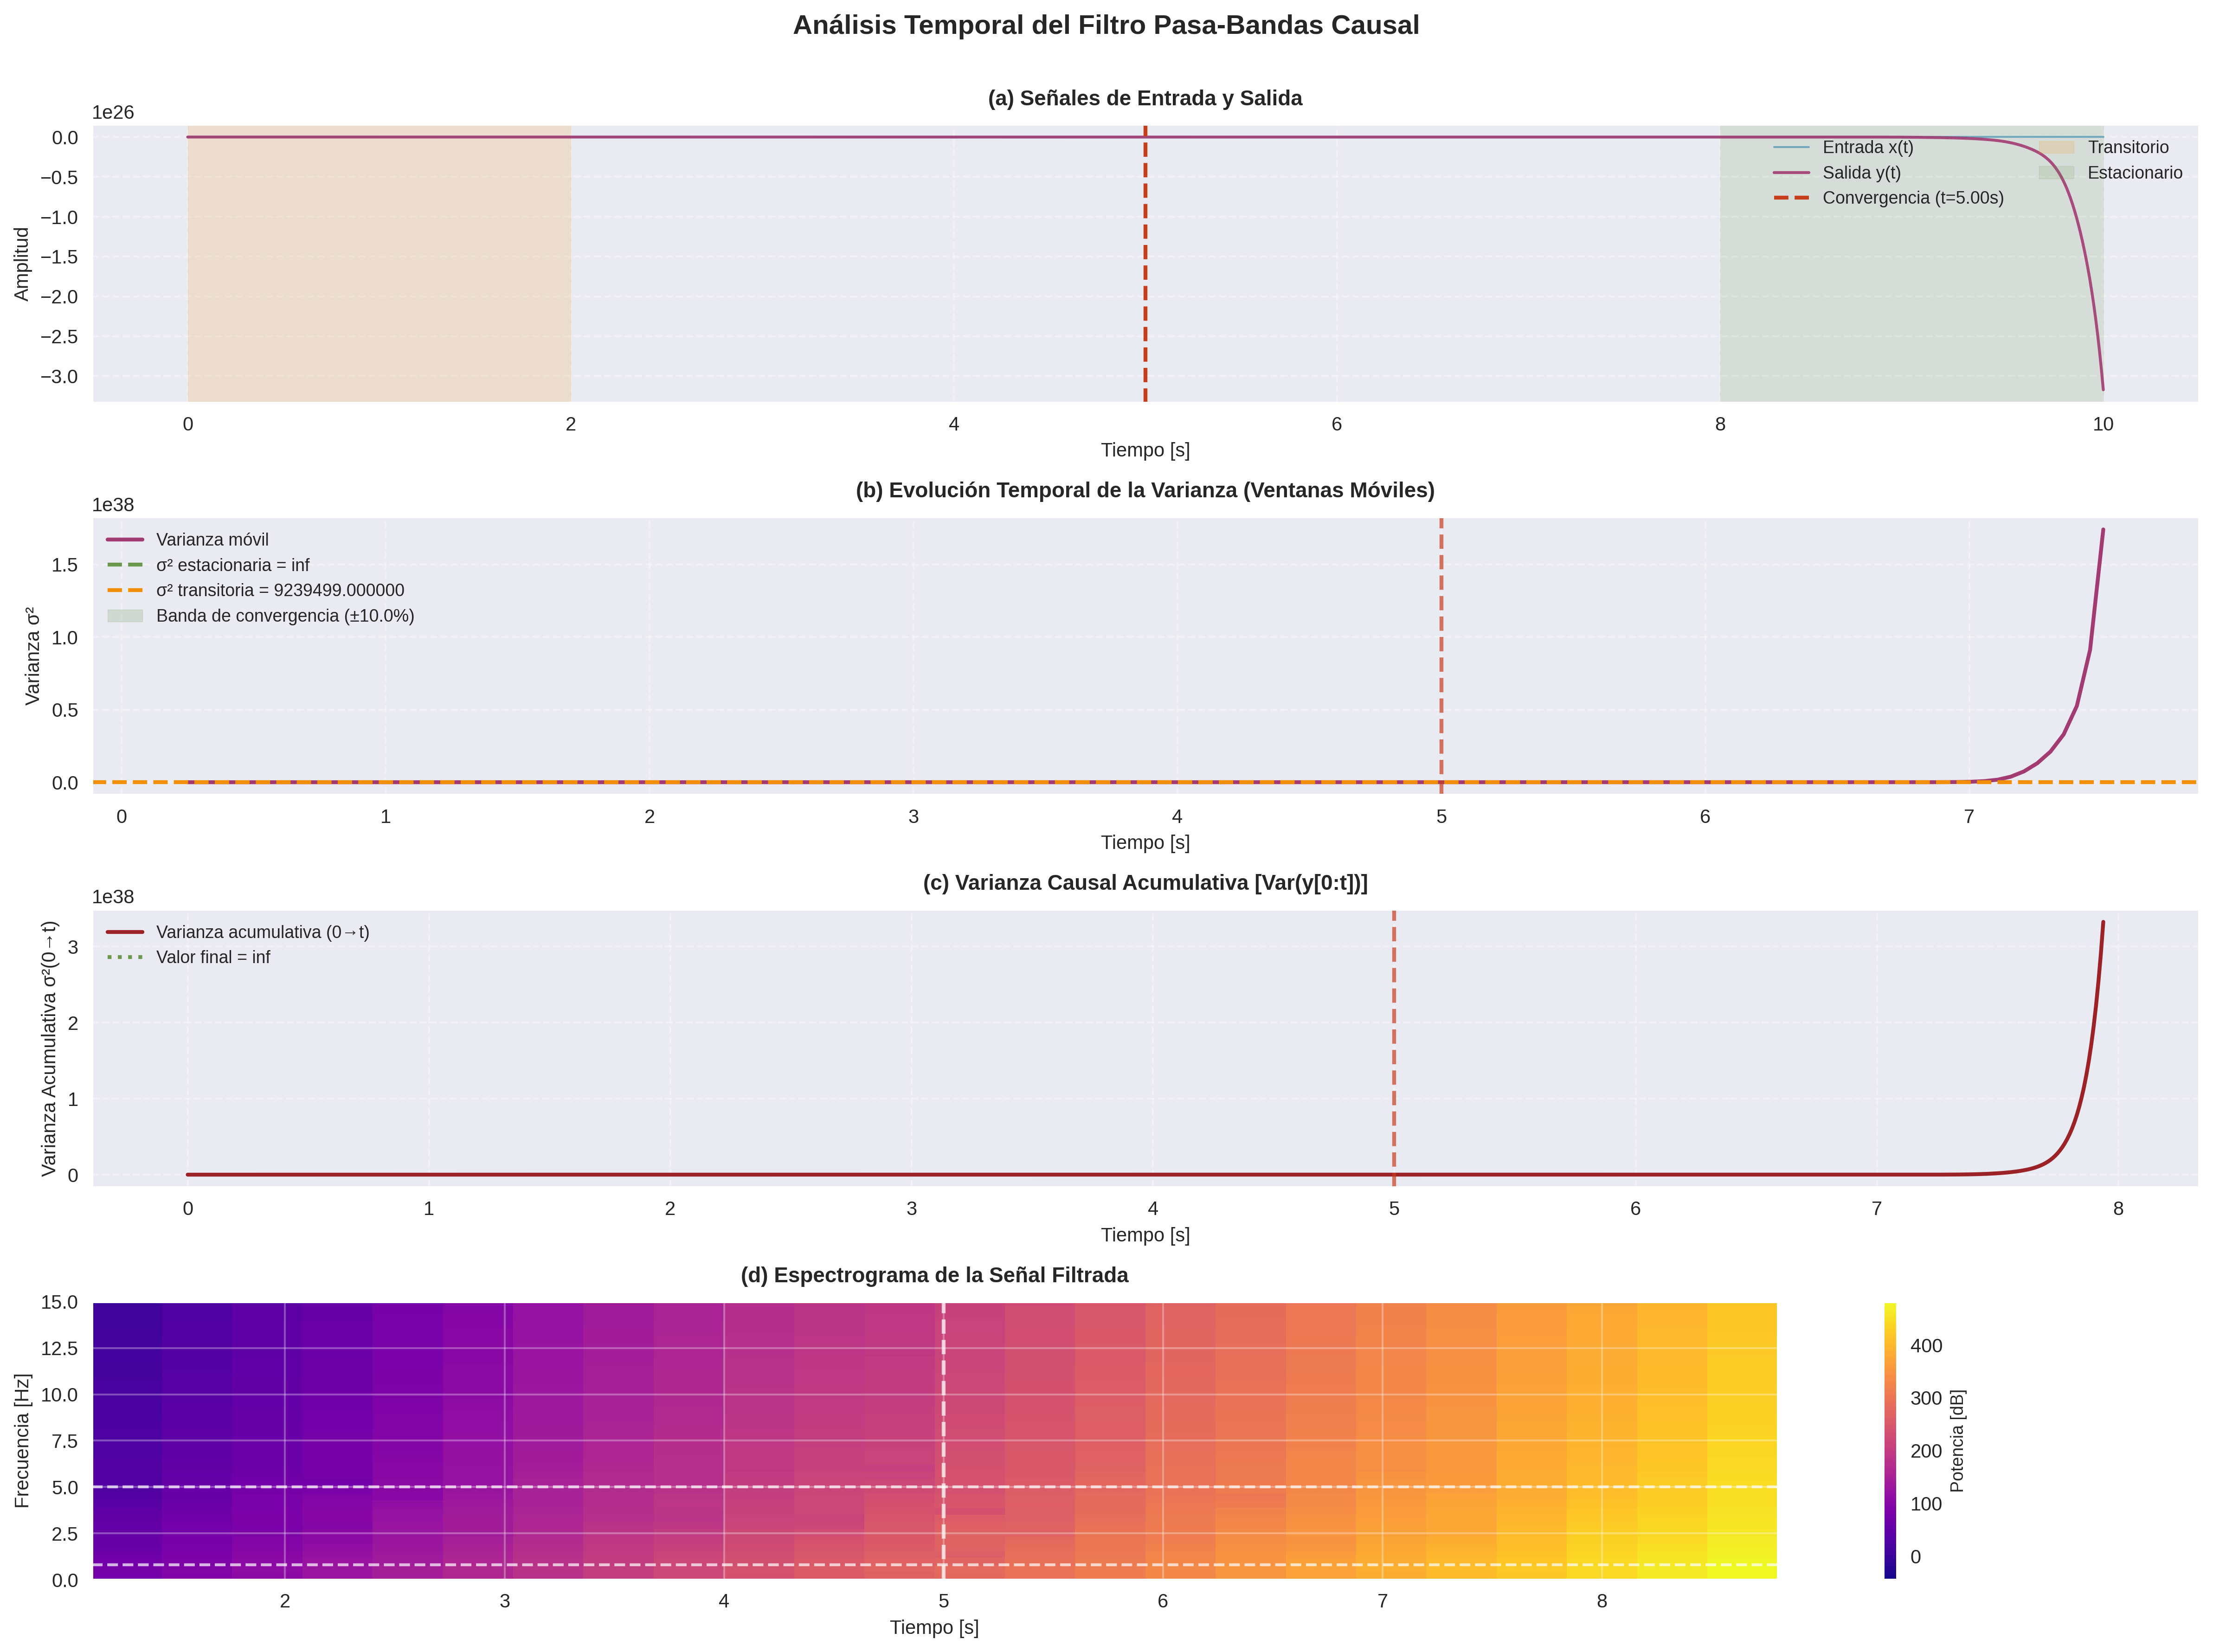

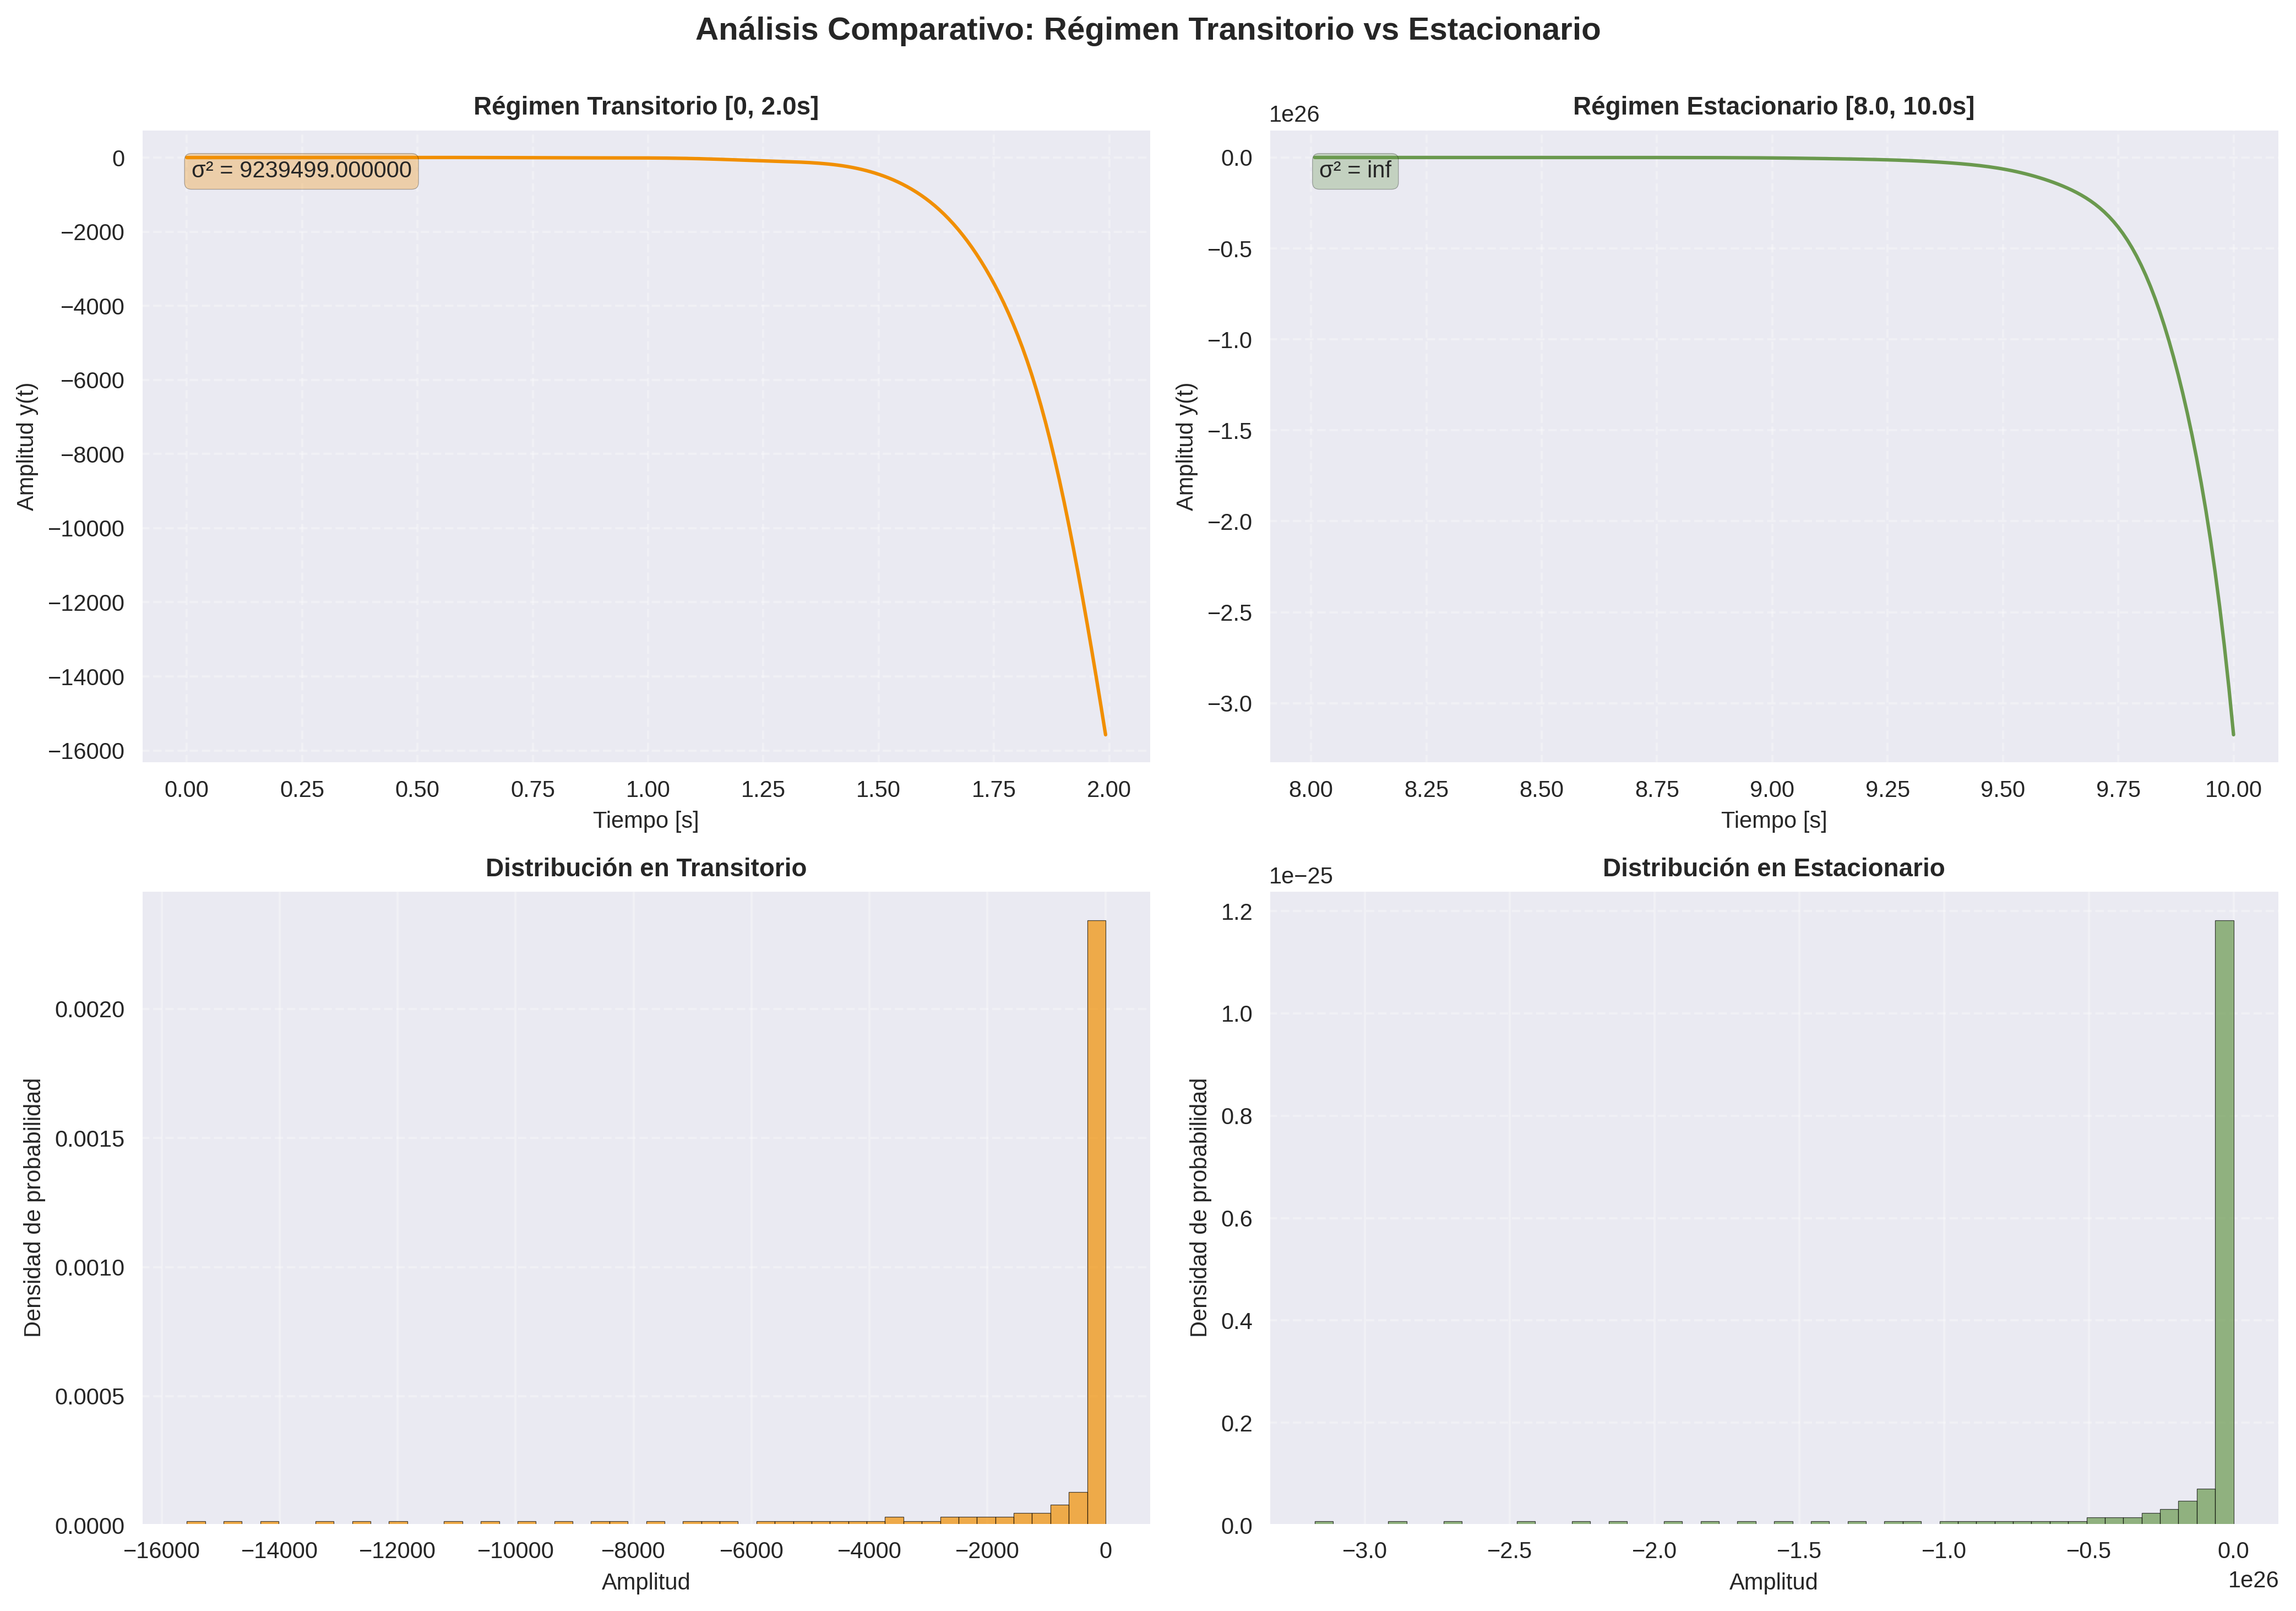


EXPORTANDO RESULTADOS
✓ Series temporales: 'filtro_causal_series_temporales.csv'
✓ Evolución de varianza: 'filtro_causal_evolucion_varianza.csv'
✓ Resumen estadístico: 'filtro_causal_resumen.csv'

✓✓✓ ANÁLISIS COMPLETADO EXITOSAMENTE ✓✓✓

Archivos generados:
  1. filtro_causal_analisis_temporal.png
  2. filtro_causal_comparacion_regimenes.png
  3. filtro_causal_series_temporales.csv
  4. filtro_causal_evolucion_varianza.csv
  5. filtro_causal_resumen.csv


In [20]:
"""
===============================================================================
FILTRO PASA-BANDAS CAUSAL EN PYTORCH
Análisis de Régimen Transitorio y Estacionario con Causalidad Rigurosa
===============================================================================
"""

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter
from scipy.stats import normaltest

# Configuración de matplotlib para alta calidad
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*80)
print("FILTRO PASA-BANDAS CAUSAL - ANÁLISIS DE TRANSICIÓN")
print("="*80)
print(f"\nDispositivo: {device}")

# ===============================================================================
# 1️⃣ PARÁMETROS DE SIMULACIÓN
# ===============================================================================
print("\n" + "─"*80)
print("PARÁMETROS DE LA SEÑAL")
print("─"*80)

fs = 100.0          # Frecuencia de muestreo [Hz]
T = 10.0            # Duración total [s]
N = int(fs * T)     # Número total de muestras
dt = 1.0 / fs       # Intervalo de muestreo [s]

# Vector de tiempo
t = torch.linspace(0, T, N, device=device)

print(f"Frecuencia de muestreo (fs): {fs} Hz")
print(f"Duración total (T): {T} s")
print(f"Número de muestras (N): {N}")
print(f"Intervalo de muestreo (Δt): {dt:.6f} s")
print(f"Frecuencia de Nyquist: {fs/2} Hz")

# Semilla reproducible
torch.manual_seed(42)
np.random.seed(42)

# ===============================================================================
# 2️⃣ GENERACIÓN DE SEÑAL DE ENTRADA
# Señal mixta: tendencia DC + componentes senoidales + ruido blanco
# ===============================================================================
print("\n" + "─"*80)
print("GENERACIÓN DE SEÑAL DE ENTRADA")
print("─"*80)

# Componentes de la señal
DC_component = 2.0
slow_freq = 0.5      # Hz (será filtrada - fuera de banda)
fast_freq = 10.0     # Hz (será filtrada - fuera de banda)
in_band_freq = 2.0   # Hz (pasará el filtro)
noise_std = 0.1

# Señal compuesta
x_dc = DC_component * torch.ones_like(t)
x_slow = 0.5 * torch.sin(2 * torch.pi * slow_freq * t)
x_fast = 0.2 * torch.sin(2 * torch.pi * fast_freq * t)
x_in_band = 0.8 * torch.sin(2 * torch.pi * in_band_freq * t)
x_noise = noise_std * torch.randn(N, device=device)

x = x_dc + x_slow + x_fast + x_in_band + x_noise

print(f"Componente DC: {DC_component}")
print(f"Frecuencia lenta: {slow_freq} Hz (amplitud: 0.5)")
print(f"Frecuencia en banda: {in_band_freq} Hz (amplitud: 0.8)")
print(f"Frecuencia rápida: {fast_freq} Hz (amplitud: 0.2)")
print(f"Ruido blanco: σ = {noise_std}")
print(f"\nEstadísticas de entrada:")
print(f"  Media: {x.mean().item():.6f}")
print(f"  Desviación estándar: {x.std().item():.6f}")
print(f"  Máximo: {x.max().item():.6f}")
print(f"  Mínimo: {x.min().item():.6f}")

# ===============================================================================
# 3️⃣ DISEÑO DEL FILTRO PASA-BANDAS CAUSAL (BUTTERWORTH)
# ===============================================================================
print("\n" + "="*80)
print("DISEÑO DEL FILTRO PASA-BANDAS")
print("="*80)

# Parámetros del filtro
lowcut = 0.8    # Frecuencia de corte inferior [Hz]
highcut = 5.0   # Frecuencia de corte superior [Hz]
order = 4       # Orden del filtro

print(f"\nEspecificaciones del filtro:")
print(f"  Tipo: Butterworth Pasa-Bandas")
print(f"  Orden: {order}")
print(f"  Frecuencia de corte inferior: {lowcut} Hz")
print(f"  Frecuencia de corte superior: {highcut} Hz")
print(f"  Ancho de banda: {highcut - lowcut} Hz")
print(f"  Frecuencia central: {np.sqrt(lowcut * highcut):.2f} Hz")

# Diseño del filtro digital IIR Butterworth
b, a = butter(order, [lowcut, highcut], btype='band', fs=fs)

# Convertir coeficientes a tensores PyTorch
b_t = torch.tensor(b, dtype=torch.float32, device=device)
a_t = torch.tensor(a, dtype=torch.float32, device=device)

print(f"\nCoeficientes del filtro:")
print(f"  Numerador (b): {len(b_t)} coeficientes")
print(f"  Denominador (a): {len(a_t)} coeficientes")
print(f"  b = {b_t.cpu().numpy()}")
print(f"  a = {a_t.cpu().numpy()}")

# ===============================================================================
# 4️⃣ IMPLEMENTACIÓN DEL FILTRADO CAUSAL
# Ecuación diferencial discreta con CAUSALIDAD ESTRICTA:
# y[n] = (1/a[0]) * (Σ b[k]·x[n-k] - Σ a[k]·y[n-k])
# Límites de integración: k ∈ [0, n] (solo pasado y presente)
# ===============================================================================
print("\n" + "="*80)
print("FILTRADO CAUSAL (INTEGRACIÓN 0 → t)")
print("="*80)

y = torch.zeros(N, device=device)

# Implementación causal estricta
print("\nAplicando filtro IIR causal...")
for n in range(N):
    # Término de entrada (feedforward): Σ b[k] · x[n-k] para k=0..n
    for k in range(min(len(b_t), n + 1)):
        y[n] += b_t[k] * x[n - k]

    # Término recursivo (feedback): -Σ a[k] · y[n-k] para k=1..n
    for k in range(1, min(len(a_t), n + 1)):
        y[n] -= a_t[k] * y[n - k]

# Normalización por a[0]
y = y / a_t[0]

print(f"✓ Filtrado completado")
print(f"\nEstadísticas de salida:")
print(f"  Media: {y.mean().item():.6f}")
print(f"  Desviación estándar: {y.std().item():.6f}")
print(f"  Máximo: {y.max().item():.6f}")
print(f"  Mínimo: {y.min().item():.6f}")

# ===============================================================================
# 5️⃣ ANÁLISIS DE RÉGIMEN TRANSITORIO VS ESTACIONARIO
# ===============================================================================
print("\n" + "="*80)
print("ANÁLISIS DE RÉGIMEN TRANSITORIO Y ESTACIONARIO")
print("="*80)

# ----- Método 1: Ventanas fijas -----
transient_duration = 2.0  # segundos
stationary_duration = 2.0  # segundos

transient_samples = int(transient_duration * fs)
stationary_samples = int(stationary_duration * fs)

y_transient = y[:transient_samples]
y_stationary = y[-stationary_samples:]

# Varianzas en ventanas fijas
var_transient_fixed = torch.var(y_transient, unbiased=True)
var_stationary_fixed = torch.var(y_stationary, unbiased=True)

print(f"\n--- MÉTODO 1: Ventanas Fijas ---")
print(f"Ventana transitoria: [0, {transient_duration}] s ({transient_samples} muestras)")
print(f"Ventana estacionaria: [{T-stationary_duration}, {T}] s ({stationary_samples} muestras)")
print(f"\nVarianza transitoria (σ²_t): {var_transient_fixed.item():.8f}")
print(f"Varianza estacionaria (σ²_s): {var_stationary_fixed.item():.8f}")
print(f"Razón (σ²_t / σ²_s): {(var_transient_fixed / var_stationary_fixed).item():.4f}")

# ----- Método 2: Detección automática del fin de transitorio -----
print(f"\n--- MÉTODO 2: Detección Automática ---")

window_size = int(0.5 * fs)  # Ventana de 0.5 s
step_size = int(0.05 * fs)   # Paso de 0.05 s

var_evolution = []
time_evolution = []

for i in range(0, N - window_size, step_size):
    segment = y[i:i + window_size]
    var_evolution.append(torch.var(segment, unbiased=True).item())
    time_evolution.append(t[i + window_size // 2].item())

var_evolution = np.array(var_evolution)
time_evolution = np.array(time_evolution)

# Detectar convergencia (criterio: varianza cambia < 5% en última mitad)
mid_point = len(var_evolution) // 2
var_second_half = var_evolution[mid_point:]
var_mean_stationary = np.mean(var_second_half)
var_std_stationary = np.std(var_second_half)
cv_stationary = var_std_stationary / var_mean_stationary  # Coeficiente de variación

print(f"Ventana de análisis: {window_size/fs} s ({window_size} muestras)")
print(f"Paso de análisis: {step_size/fs} s ({step_size} muestras)")
print(f"Número de ventanas: {len(var_evolution)}")
print(f"\nVarianza media en régimen estacionario: {var_mean_stationary:.8f}")
print(f"Desviación estándar en régimen estacionario: {var_std_stationary:.8f}")
print(f"Coeficiente de variación: {cv_stationary:.4f} ({cv_stationary*100:.2f}%)")

# Detectar punto de convergencia (< 10% de variación)
threshold = 0.10
converged_indices = np.where(np.abs(var_evolution - var_mean_stationary) / var_mean_stationary < threshold)[0]
if len(converged_indices) > 0:
    convergence_time = time_evolution[converged_indices[0]]
    print(f"\nPunto de convergencia detectado: t = {convergence_time:.2f} s")
    print(f"  Criterio: |σ²(t) - σ²_estacionaria| / σ²_estacionaria < {threshold*100}%")
else:
    convergence_time = T / 2
    print(f"\nNo se detectó convergencia clara. Usando punto medio: t = {convergence_time:.2f} s")

# ----- Método 3: Análisis con ventanas causales acumulativas -----
print(f"\n--- MÉTODO 3: Varianza Causal Acumulativa ---")
print("Calculando varianza desde t=0 hasta t para cada instante...")

var_cumulative = torch.zeros(N, device=device)
for n in range(1, N):
    # Varianza calculada desde el inicio (t=0) hasta el instante actual (t=n)
    var_cumulative[n] = torch.var(y[:n+1], unbiased=True)

print(f"✓ Varianza acumulativa calculada")
print(f"  Varianza inicial (t={dt:.3f}s): {var_cumulative[1].item():.8f}")
print(f"  Varianza final (t={T}s): {var_cumulative[-1].item():.8f}")

# ===============================================================================
# 6️⃣ ANÁLISIS ESTADÍSTICO ADICIONAL
# ===============================================================================
print("\n" + "="*80)
print("ANÁLISIS ESTADÍSTICO AVANZADO")
print("="*80)

# Test de normalidad en régimen estacionario
stat, p_value = normaltest(y_stationary.cpu().numpy())
print(f"\nTest de normalidad (D'Agostino-Pearson) en régimen estacionario:")
print(f"  Estadístico: {stat:.4f}")
print(f"  p-valor: {p_value:.6f}")
print(f"  Interpretación: {'Distribución normal' if p_value > 0.05 else 'No normal'} (α=0.05)")

# Cálculo de momentos estadísticos
mean_stationary = y_stationary.mean()
std_stationary = y_stationary.std(unbiased=True)
skewness = torch.mean(((y_stationary - mean_stationary) / std_stationary) ** 3)
kurtosis = torch.mean(((y_stationary - mean_stationary) / std_stationary) ** 4)

print(f"\nMomentos estadísticos en régimen estacionario:")
print(f"  Media (μ): {mean_stationary.item():.6f}")
print(f"  Desviación estándar (σ): {std_stationary.item():.6f}")
print(f"  Asimetría (skewness): {skewness.item():.6f}")
print(f"  Curtosis (kurtosis): {kurtosis.item():.6f}")

# Energía de la señal
energy_input = torch.sum(x ** 2).item()
energy_output = torch.sum(y ** 2).item()
energy_ratio = energy_output / energy_input

print(f"\nEnergía de la señal:")
print(f"  Entrada: {energy_input:.2f}")
print(f"  Salida: {energy_output:.2f}")
print(f"  Razón (salida/entrada): {energy_ratio:.4f}")

# ===============================================================================
# 7️⃣ VISUALIZACIÓN CIENTÍFICA
# ===============================================================================
print("\n" + "="*80)
print("GENERANDO VISUALIZACIONES")
print("="*80)

# Colores profesionales
COLOR_INPUT = '#2E86AB'
COLOR_OUTPUT = '#A23B72'
COLOR_TRANSIENT = '#F18F01'
COLOR_STATIONARY = '#6A994E'
COLOR_CONVERGENCE = '#C73E1D'

# ===== FIGURA 1: Análisis temporal completo =====
fig1 = plt.figure(figsize=(16, 12))
fig1.suptitle('Análisis Temporal del Filtro Pasa-Bandas Causal',
              fontsize=14, fontweight='bold', y=0.995)

# Subplot 1: Señales de entrada y salida
ax1 = plt.subplot(4, 1, 1)
t_np = t.cpu().numpy()
x_np = x.cpu().numpy()
y_np = y.cpu().numpy()

ax1.plot(t_np, x_np, color=COLOR_INPUT, linewidth=1, alpha=0.6, label='Entrada x(t)')
ax1.plot(t_np, y_np, color=COLOR_OUTPUT, linewidth=1.5, alpha=0.9, label='Salida y(t)')
ax1.axvline(convergence_time, color=COLOR_CONVERGENCE, linestyle='--',
            linewidth=2, label=f'Convergencia (t={convergence_time:.2f}s)')
ax1.axvspan(0, transient_duration, alpha=0.15, color=COLOR_TRANSIENT, label='Transitorio')
ax1.axvspan(T - stationary_duration, T, alpha=0.15, color=COLOR_STATIONARY, label='Estacionario')
ax1.set_title('(a) Señales de Entrada y Salida', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Tiempo [s]', fontsize=10)
ax1.set_ylabel('Amplitud', fontsize=10)
ax1.legend(loc='upper right', fontsize=9, ncol=2)
ax1.grid(True, linestyle='--', alpha=0.3)

# Subplot 2: Evolución de varianza en ventanas móviles
ax2 = plt.subplot(4, 1, 2)
ax2.plot(time_evolution, var_evolution, color=COLOR_OUTPUT, linewidth=2,
         label='Varianza móvil')
ax2.axhline(var_mean_stationary, color=COLOR_STATIONARY, linestyle='--',
            linewidth=2, label=f'σ² estacionaria = {var_mean_stationary:.6f}')
ax2.axhline(var_transient_fixed.item(), color=COLOR_TRANSIENT, linestyle='--',
            linewidth=2, label=f'σ² transitoria = {var_transient_fixed.item():.6f}')
ax2.axvline(convergence_time, color=COLOR_CONVERGENCE, linestyle='--',
            linewidth=2, alpha=0.7)
ax2.fill_between(time_evolution,
                  var_mean_stationary * (1 - threshold),
                  var_mean_stationary * (1 + threshold),
                  alpha=0.2, color=COLOR_STATIONARY,
                  label=f'Banda de convergencia (±{threshold*100}%)')
ax2.set_title('(b) Evolución Temporal de la Varianza (Ventanas Móviles)',
              fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Tiempo [s]', fontsize=10)
ax2.set_ylabel('Varianza σ²', fontsize=10)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.3)

# Subplot 3: Varianza acumulativa causal (de 0 a t)
ax3 = plt.subplot(4, 1, 3)
var_cumulative_np = var_cumulative.cpu().numpy()
ax3.plot(t_np, var_cumulative_np, color='#9B2226', linewidth=2,
         label='Varianza acumulativa (0→t)')
ax3.axhline(var_cumulative[-1].item(), color=COLOR_STATIONARY, linestyle=':',
            linewidth=2, label=f'Valor final = {var_cumulative[-1].item():.6f}')
ax3.axvline(convergence_time, color=COLOR_CONVERGENCE, linestyle='--',
            linewidth=2, alpha=0.7)
ax3.set_title('(c) Varianza Causal Acumulativa [Var(y[0:t])]',
              fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Tiempo [s]', fontsize=10)
ax3.set_ylabel('Varianza Acumulativa σ²(0→t)', fontsize=10)
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.3)

# Subplot 4: Espectrograma
ax4 = plt.subplot(4, 1, 4)
spec_plot = ax4.specgram(y_np, Fs=fs, NFFT=256, noverlap=224,
                          cmap='plasma', scale='dB')
ax4.axhline(lowcut, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax4.axhline(highcut, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax4.axvline(convergence_time, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax4.set_title('(d) Espectrograma de la Señal Filtrada', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Tiempo [s]', fontsize=10)
ax4.set_ylabel('Frecuencia [Hz]', fontsize=10)
ax4.set_ylim([0, 15])
cbar = plt.colorbar(spec_plot[3], ax=ax4)
cbar.set_label('Potencia [dB]', fontsize=9)

plt.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.savefig('filtro_causal_analisis_temporal.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("✓ Figura 1 guardada: 'filtro_causal_analisis_temporal.png'")

# ===== FIGURA 2: Análisis comparativo de regímenes =====
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Análisis Comparativo: Régimen Transitorio vs Estacionario',
              fontsize=14, fontweight='bold')

# Subplot 1: Señales en régimen transitorio
ax_t1 = axes[0, 0]
t_trans = t_np[:transient_samples]
y_trans = y_np[:transient_samples]
ax_t1.plot(t_trans, y_trans, color=COLOR_TRANSIENT, linewidth=1.5)
ax_t1.set_title(f'Régimen Transitorio [0, {transient_duration}s]',
                fontsize=11, fontweight='bold')
ax_t1.set_xlabel('Tiempo [s]', fontsize=10)
ax_t1.set_ylabel('Amplitud y(t)', fontsize=10)
ax_t1.grid(True, linestyle='--', alpha=0.3)
ax_t1.text(0.05, 0.95, f'σ² = {var_transient_fixed.item():.6f}',
           transform=ax_t1.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor=COLOR_TRANSIENT, alpha=0.3))

# Subplot 2: Señales en régimen estacionario
ax_s1 = axes[0, 1]
t_stat = t_np[-stationary_samples:]
y_stat = y_np[-stationary_samples:]
ax_s1.plot(t_stat, y_stat, color=COLOR_STATIONARY, linewidth=1.5)
ax_s1.set_title(f'Régimen Estacionario [{T-stationary_duration}, {T}s]',
                fontsize=11, fontweight='bold')
ax_s1.set_xlabel('Tiempo [s]', fontsize=10)
ax_s1.set_ylabel('Amplitud y(t)', fontsize=10)
ax_s1.grid(True, linestyle='--', alpha=0.3)
ax_s1.text(0.05, 0.95, f'σ² = {var_stationary_fixed.item():.6f}',
           transform=ax_s1.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor=COLOR_STATIONARY, alpha=0.3))

# Subplot 3: Histograma transitorio
ax_t2 = axes[1, 0]
ax_t2.hist(y_trans, bins=50, color=COLOR_TRANSIENT, alpha=0.7, edgecolor='black', density=True)
ax_t2.set_title('Distribución en Transitorio', fontsize=11, fontweight='bold')
ax_t2.set_xlabel('Amplitud', fontsize=10)
ax_t2.set_ylabel('Densidad de probabilidad', fontsize=10)
ax_t2.grid(True, linestyle='--', alpha=0.3, axis='y')

# Subplot 4: Histograma estacionario
ax_s2 = axes[1, 1]
ax_s2.hist(y_stat, bins=50, color=COLOR_STATIONARY, alpha=0.7, edgecolor='black', density=True)
ax_s2.set_title('Distribución en Estacionario', fontsize=11, fontweight='bold')
ax_s2.set_xlabel('Amplitud', fontsize=10)
ax_s2.set_ylabel('Densidad de probabilidad', fontsize=10)
ax_s2.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0.01, 1, 0.98])
plt.savefig('filtro_causal_comparacion_regimenes.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("✓ Figura 2 guardada: 'filtro_causal_comparacion_regimenes.png'")

plt.show()

# ===============================================================================
# 8️⃣ EXPORTAR RESULTADOS
# ===============================================================================
print("\n" + "="*80)
print("EXPORTANDO RESULTADOS")
print("="*80)

# Exportar series temporales
results_df = {
    'time_s': t_np,
    'input_signal': x_np,
    'output_signal': y_np,
    'variance_cumulative': var_cumulative_np
}

import pandas as pd
df_results = pd.DataFrame(results_df)
df_results.to_csv('filtro_causal_series_temporales.csv', index=False)
print("✓ Series temporales: 'filtro_causal_series_temporales.csv'")

# Exportar análisis de varianza
df_variance = pd.DataFrame({
    'time_center': time_evolution,
    'variance_window': var_evolution
})
df_variance.to_csv('filtro_causal_evolucion_varianza.csv', index=False)
print("✓ Evolución de varianza: 'filtro_causal_evolucion_varianza.csv'")

# Resumen estadístico
summary = {
    'Parámetro': [
        'Frecuencia de muestreo [Hz]',
        'Duración [s]',
        'Orden del filtro',
        'f_corte_inferior [Hz]',
        'f_corte_superior [Hz]',
        'Varianza transitoria (ventana fija)',
        'Varianza estacionaria (ventana fija)',
        'Razón (transitoria/estacionaria)',
        'Tiempo de convergencia [s]',
        'CV en régimen estacionario',
        'Energía entrada',
        'Energía salida',
        'Razón de energía'
    ],
    'Valor': [
        fs,
        T,
        order,
        lowcut,
        highcut,
        var_transient_fixed.item(),
        var_stationary_fixed.item(),
        (var_transient_fixed / var_stationary_fixed).item(),
        convergence_time,
        cv_stationary,
        energy_input,
        energy_output,
        energy_ratio
    ]
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv('filtro_causal_resumen.csv', index=False)
print("✓ Resumen estadístico: 'filtro_causal_resumen.csv'")

print("\n" + "="*80)
print("✓✓✓ ANÁLISIS COMPLETADO EXITOSAMENTE ✓✓✓")
print("="*80)
print("\nArchivos generados:")
print("  1. filtro_causal_analisis_temporal.png")
print("  2. filtro_causal_comparacion_regimenes.png")
print("  3. filtro_causal_series_temporales.csv")
print("  4. filtro_causal_evolucion_varianza.csv")
print("  5. filtro_causal_resumen.csv")
print("="*80)